# Generate mock data

In [ ]:
import agama
agama.setUnits(mass=1, length=1, velocity=1)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle

logM_NFW = np.log10(5e11)
scaleRadius_NFW = 15.0
logM_disc = np.log10(4e10)
scaleRadius_disc = 3.0
scaleHeight_disc = 0.5
sigmaR0 = 50.0
R_sigmaR = 6.0

pot_nfw = agama.Potential(type='NFW', mass=10**logM_NFW, scaleRadius=scaleRadius_NFW)
# pot_nfw = agama.Potential(type='Spheroid', densityNorm=4.34527e9, gamma=1.0, beta=3.0, scaleRadius=2.0)
pot_disc = agama.Potential(type='MiyamotoNagai', mass=10**logM_disc, scaleRadius=scaleRadius_disc, scaleHeight=scaleHeight_disc)

pot = agama.Potential(pot_nfw, pot_disc)

af = agama.ActionFinder(potential=pot)

df = agama.DistributionFunction(type='QuasiIsothermal', potential=pot,
                                mass = 10**logM_disc, Rdisk = scaleRadius_disc, Hdisk = scaleHeight_disc,
                                sigmar0 = sigmaR0, Rsigmar = R_sigmaR)

gm = agama.GalaxyModel(potential=pot, df=df, af=af)

posvel, mass = gm.sample(int(1e7))

Text(0, 0.5, 'Z [kpc]')

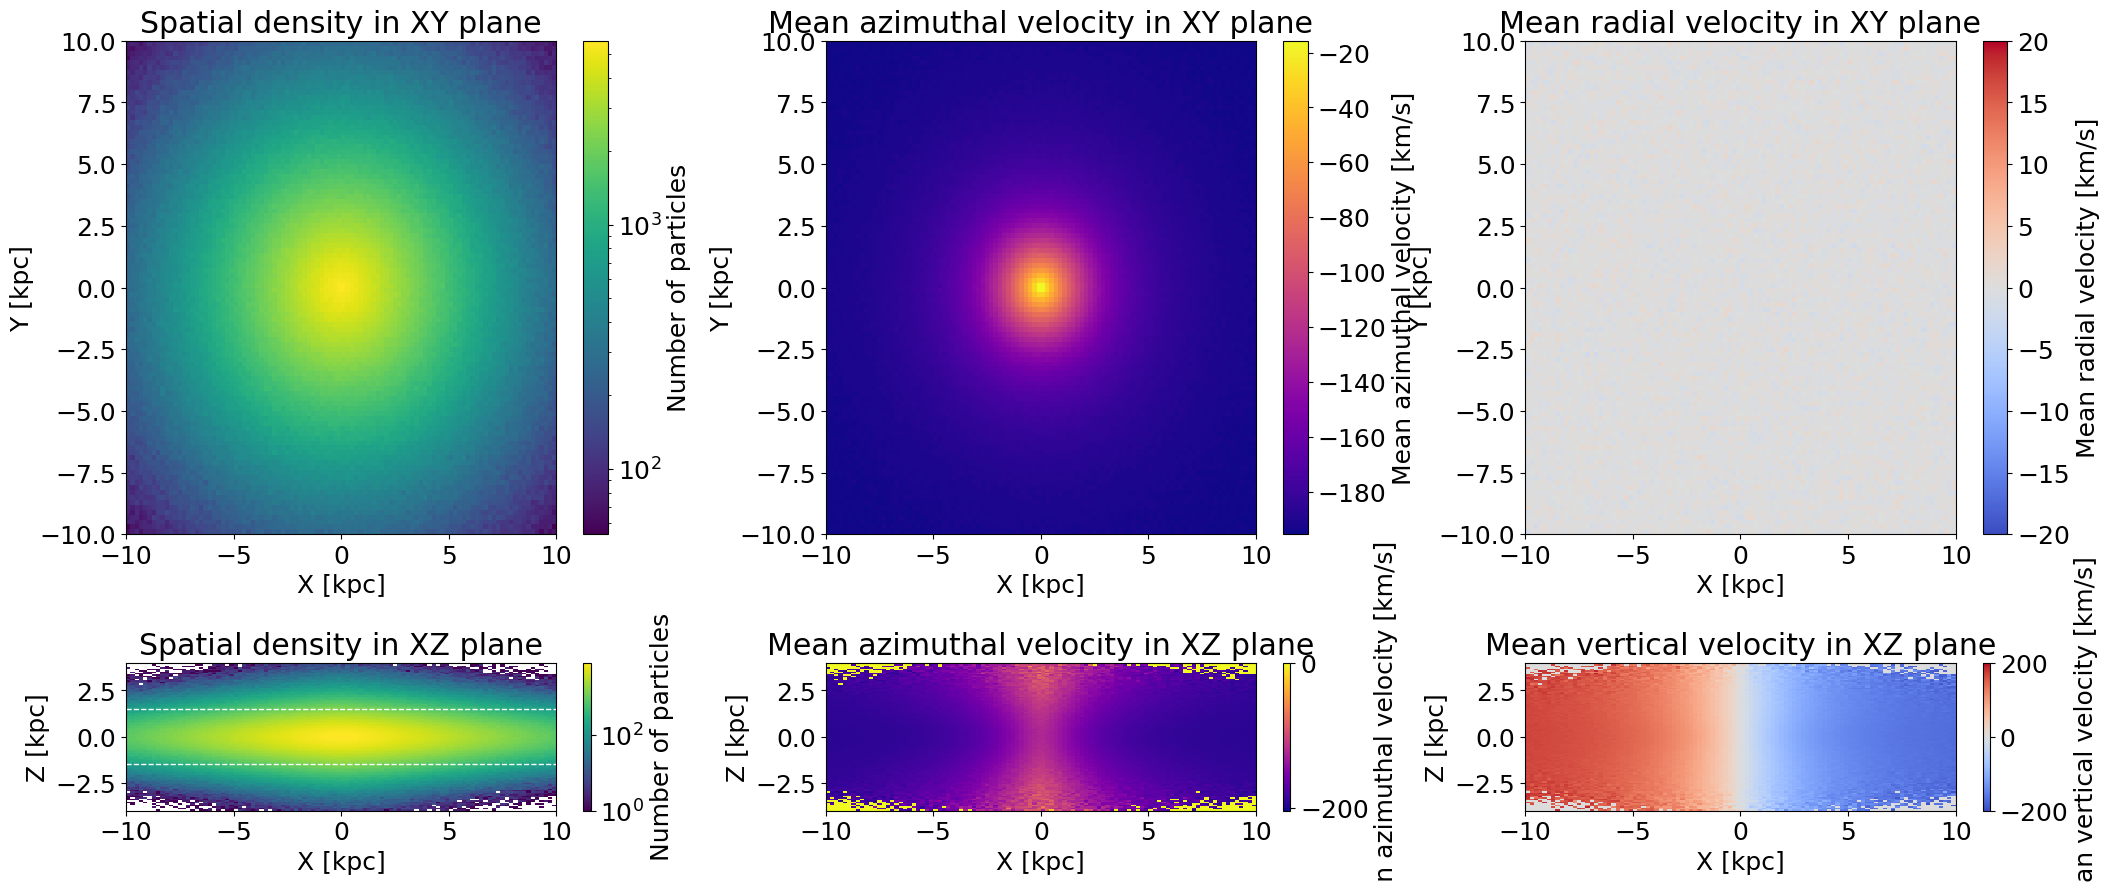

In [324]:
x, y, z, vx, vy, vz = posvel.T
x, vx = -x, -vx
R, phi, z = np.sqrt(x**2 + y**2), np.arctan2(y, x), z
vR = (x*vx + y*vy) / R
vphi = (x*vy - y*vx) / R
vz = vz

ground_truth_params = {
        'halo_params':{
            'logM': logM_NFW,
            'scaleRadius': scaleRadius_NFW
        },
        'disc_params':{
            'logM': logM_disc,
            'scaleRadius': scaleRadius_disc,
            'scaleHeight': scaleHeight_disc,
            'sigmaR0': sigmaR0,
            'R_sigmaR': R_sigmaR
        }
    }

data_mock = {
    'x':x,
    'y':y,
    'z':z,
    'vx':vx,
    'vy':vy,
    'vz':vz,
    'mass':mass,
    'ground_truth': ground_truth_params
}

with open('/home/hz420/python_script/SchwarMAX/mock_axisymmetric_disc_potential_params.pkl', 'wb') as f:
    pickle.dump(ground_truth_params, f)

with open('/data/hz420-2/SchwarMAX/mock_axisymmetric_disc.pkl', 'wb') as f:
    pickle.dump(data_mock, f)

fig, ax = plt.subplots(2,3, figsize = (25, 10), gridspec_kw={'hspace':0.4, 'wspace':0.3, 'height_ratios': [1,0.3]})

H, xedges, yedges = np.histogram2d(x, y, bins=100, range=[[-10,10],[-10,10]])
H_vR = np.histogram2d(x, y, bins=100, range=[[-10,10],[-10,10]], weights=vR)[0] / (H + 1e-8)
H_vphi = np.histogram2d(x, y, bins=100, range=[[-10,10],[-10,10]], weights=vphi)[0] / (H + 1e-8)

cb = ax[0,0].pcolormesh(xedges, yedges, H.T, norm=mpl.colors.LogNorm(), cmap='viridis')
fig.colorbar(cb, ax=ax[0,0], label='Number of particles')
ax[0,0].set_title('Spatial density in XY plane')
ax[0,0].set_xlabel('X [kpc]')
ax[0,0].set_ylabel('Y [kpc]')
cb2 = ax[0,1].pcolormesh(xedges, yedges, H_vphi.T, cmap='plasma')
fig.colorbar(cb2, ax=ax[0,1], label='Mean azimuthal velocity [km/s]')
ax[0,1].set_title('Mean azimuthal velocity in XY plane')
ax[0,1].set_xlabel('X [kpc]')
ax[0,1].set_ylabel('Y [kpc]')
cb3 = ax[0,2].pcolormesh(xedges, yedges, H_vR.T, cmap='coolwarm', vmin = -20, vmax = 20)
fig.colorbar(cb3, ax=ax[0,2], label='Mean radial velocity [km/s]')
ax[0,2].set_title('Mean radial velocity in XY plane')
ax[0,2].set_xlabel('X [kpc]')
ax[0,2].set_ylabel('Y [kpc]')

H, xedges, yedges = np.histogram2d(x, z, bins=100, range=[[-10,10],[-4,4]])
H_vy = np.histogram2d(x, z, bins=100, range=[[-10,10],[-4,4]], weights=vy)[0] / (H + 1e-8)
H_vphi = np.histogram2d(x, z, bins=100, range=[[-10,10],[-4,4]], weights=vphi)[0] / (H + 1e-8)

cb4 = ax[1,0].pcolormesh(xedges, yedges, H.T, norm=mpl.colors.LogNorm(), cmap='viridis')
fig.colorbar(cb4, ax=ax[1,0], label='Number of particles')
ax[1,0].set_title('Spatial density in XZ plane')
ax[1,0].set_xlabel('X [kpc]')
ax[1,0].set_ylabel('Z [kpc]')
ax[1,0].axhline(1.5, color='white', linestyle='--', linewidth=1)
ax[1,0].axhline(-1.5, color='white', linestyle='--', linewidth=1)
cb5 = ax[1,1].pcolormesh(xedges, yedges, H_vphi.T, cmap='plasma')
fig.colorbar(cb5, ax=ax[1,1], label='Mean azimuthal velocity [km/s]')
ax[1,1].set_title('Mean azimuthal velocity in XZ plane')
ax[1,1].set_xlabel('X [kpc]')
ax[1,1].set_ylabel('Z [kpc]')
cb6 = ax[1,2].pcolormesh(xedges, yedges, H_vy.T, cmap='coolwarm', vmin = -200, vmax = 200)
fig.colorbar(cb6, ax=ax[1,2], label='Mean vertical velocity [km/s]')
ax[1,2].set_title('Mean vertical velocity in XZ plane')
ax[1,2].set_xlabel('X [kpc]')
ax[1,2].set_ylabel('Z [kpc]')


# Generate an initial condition

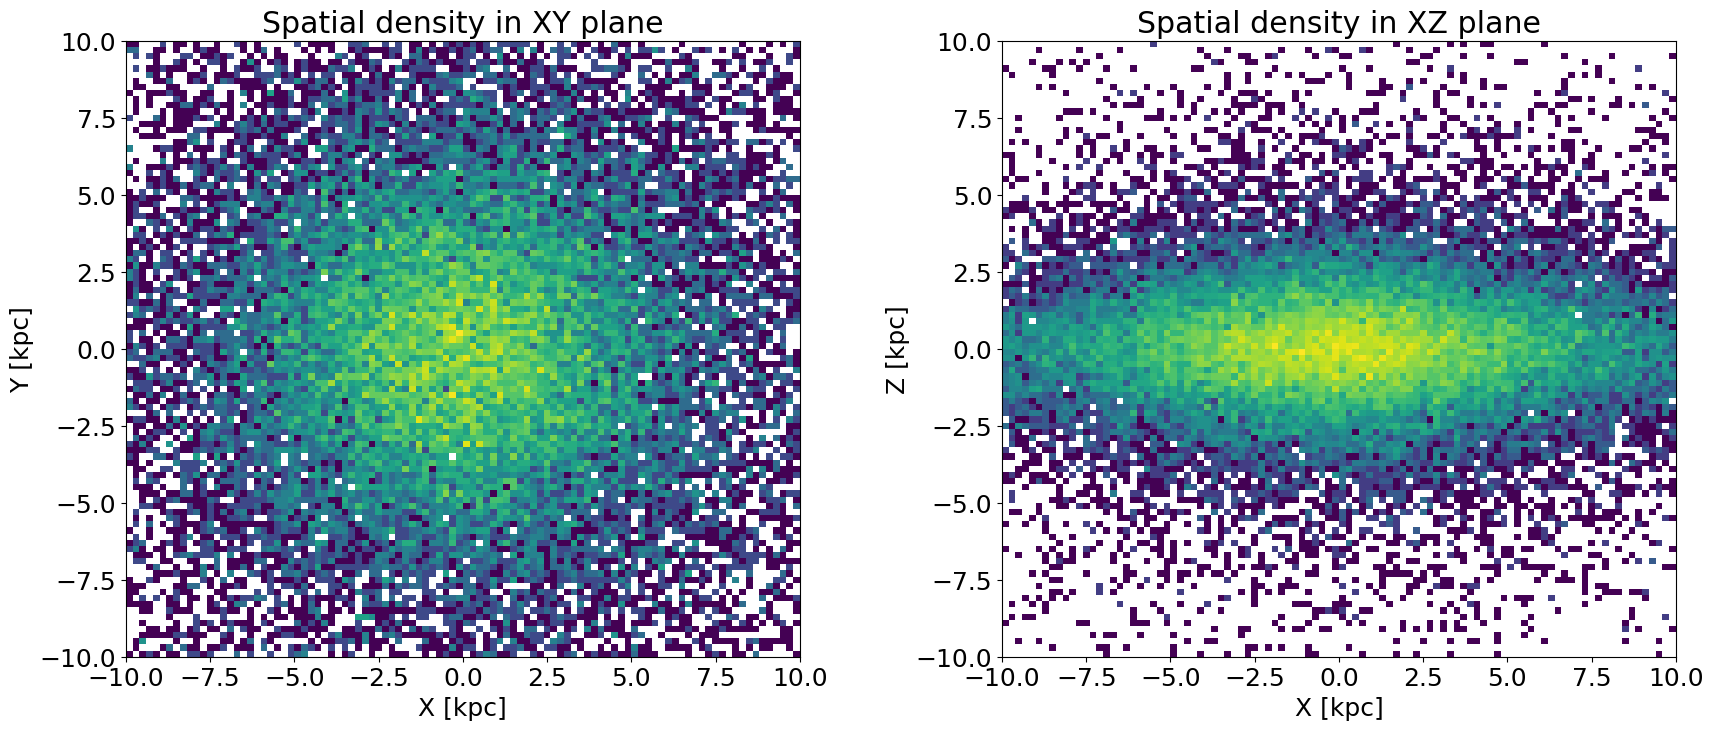

In [334]:
import agama
agama.setUnits(mass=1, length=1, velocity=1)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

logM_disc = np.log10(5e10)
scaleRadius_disc = 4.0
scaleHeight_disc = 2.

pot_disc = agama.Potential(type='MiyamotoNagai', mass=10**logM_disc, scaleRadius=scaleRadius_disc, scaleHeight=scaleHeight_disc)

posvel, mass = pot_disc.sample(int(5e4))

fig, ax = plt.subplots(1,2, figsize = (20, 8), gridspec_kw={'hspace':0.4, 'wspace':0.3})
ax[0].hist2d(posvel[:,0], posvel[:,1], bins=100, range=[[-10,10],[-10,10]], norm=mpl.colors.LogNorm(), cmap='viridis')
ax[0].set_title('Spatial density in XY plane')
ax[0].set_xlabel('X [kpc]')
ax[0].set_ylabel('Y [kpc]')

ax[1].hist2d(posvel[:,0], posvel[:,2], bins=100, range=[[-10,10],[-10,10]], norm=mpl.colors.LogNorm(), cmap='viridis')
ax[1].set_title('Spatial density in XZ plane')
ax[1].set_xlabel('X [kpc]')
ax[1].set_ylabel('Z [kpc]')

ic_dict = {
    'x': posvel[:,0],
    'y': posvel[:,1],
    'z': posvel[:,2],
    'mass': mass
}

# with open('/home/hz420/python_script/SchwarMAX/mock_initial_conditions_xyz.pkl', 'wb') as f:
#     pickle.dump(ic_dict, f)
pd.DataFrame(ic_dict).to_csv('/home/hz420/python_script/SchwarMAX/mock_initial_conditions_xyz.csv', index=False)

# First pipeline 2026/01/12
### (no GH constraints, 3D density for orbital weights, and kinematics for hyperparameters)

In [1]:

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants import *
from utils import *

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc

path = '/home/hz420/python_script/SchwarMAX/'

In [2]:
@jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned = model(params_halo_pot, params_disk_rho, dict_data)
    vr_binned = jnp.where(jnp.isnan(vr_binned), 0.0, vr_binned)
    sigmavr_binned = jnp.where(jnp.isnan(sigmavr_binned), 0.0, sigmavr_binned)
    vphi_binned = jnp.where(jnp.isnan(vphi_binned), 0.0, vphi_binned)
    sigmavphi_binned = jnp.where(jnp.isnan(sigmavphi_binned), 0.0, sigmavphi_binned)
    vz_binned = jnp.where(jnp.isnan(vz_binned), 0.0, vz_binned)
    sigmavz_binned = jnp.where(jnp.isnan(sigmavz_binned), 0.0, sigmavz_binned)

    frac_err = 0.1

    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vr_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vphi_data_binned'] - vphi_binned)**2) / (frac_err * dict_data['vphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['vz_data_binned'] - vz_binned)**2) / (frac_err * dict_data['vz_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavr_data_binned'] - sigmavr_binned)**2) / (frac_err * dict_data['sigmavr_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavphi_data_binned'] - sigmavphi_binned)**2) / (frac_err * dict_data['sigmavphi_data_binned'] + 1e-3) )
    log_likelihood += jnp.nansum( -0.5 * ((dict_data['sigmavz_data_binned'] - sigmavz_binned)**2) / (frac_err * dict_data['sigmavz_data_binned'] + 1e-3) )

    return log_likelihood

@jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    time, xv = jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None))(dict_data['w0'], acc_fn, n_steps, dt, initial_time, unroll)
    density_model = jax.vmap(histogram3d)(xv[:, :, :3], None)

    A = density_model.reshape(len(xv), -1).T.astype(jnp.float32)/n_steps
    y = dict_data['density_data'].reshape(-1).astype(jnp.float32)
    sig = 0.01 * y + 1 # jnp.sqrt(y + 1.0).astype(jnp.float32)  # Poisson noise + 1.0 floor

    weights = solve_lbfgs_softplus(A, y, sig, l2=1e-3, maxiter=300)

    weights_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), jnp.repeat(weights, n_steps).ravel())

    r_model    = jnp.linalg.norm(xv[:, :, :2], axis=-1)
    vr_model   = (xv[:, :, 0] * xv[:, :, 3] + xv[:, :, 1] * xv[:, :, 4]) / r_model
    vr_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vr2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavr_binned = jnp.sqrt(jnp.clip(vr2_binned - vr_binned**2, a_min=0.0))

    vphi = -(-xv[:, :, 1] * xv[:, :, 3] + xv[:, :, 0] * xv[:, :, 4]) / r_model
    vphi_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vphi2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavphi_binned = jnp.sqrt(jnp.clip(vphi2_binned - vphi_binned**2, a_min=0.0))

    vz_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]*weights[:, None]).ravel())/(weights_binned+EPSILON)
    vz2_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
    sigmavz_binned = jnp.sqrt(jnp.clip(vz2_binned - vz_binned**2, a_min=0.0))

    return vr_binned, sigmavr_binned, vphi_binned, sigmavphi_binned, vz_binned, sigmavz_binned

@jax.jit
def _nll_z(z, A, y, sig, l2):
    x = jnn.softplus(z)  # strictly positive
    r = (A @ x - y) / sig
    return 0.5 * jnp.dot(r, r) + 0.5 * l2 * jnp.dot(x, x)
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A, y, sigma, l2=1e-3, maxiter=500, tol=1e-6):
    z0 = jnp.zeros(A.shape[1], A.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, A, y, sigma, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat

In [6]:


with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}


logL = logl(ground_truth, dict_data)
print(logL)

10000
-64194924.0


In [ ]:
from tqdm import tqdm

N = 20
for i in tqdm(range (0, N)):

  dict_param = {
          'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
          'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
          'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
          'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
          'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
  }

  logL = logl(dict_param, dict_data)
  print(logL)

# Second pipeline 2026/01/19
### (add ic sampling, 3D density + 2D density + 2D h1-h4 for orbital weights, and V, sigma, h3, h4 for hyperparameters)

In [1]:
%load_ext autoreload
%autoreload 2

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

path = '/home/hz420/python_script/SchwarMAX/'

## Generating a mock data file for 3D density, 2D density and kinematics (assuming perfect edge-on)

In [102]:
EPSILON = 1e-12

# Load data
with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T

x, y = w0_data[:, 0], w0_data[:, 1]
R, phi = jnp.sqrt(w0_data[:, 0]**2 + w0_data[:, 1]**2), jnp.arctan2(w0_data[:, 1], w0_data[:, 0])
z, vy = w0_data[:, 2], w0_data[:, 4]

x = np.random.normal(x, 0., size=x.shape)
y = np.random.normal(y, 0., size=y.shape)
z = np.random.normal(z, 0., size=z.shape)

Rzphi_stars = jnp.stack([R, z, phi], axis=-1)
XY_stars = jnp.stack([x, z], axis=-1) # prefect edge-on view
print('Rzphi_stars shape:', Rzphi_stars.shape, 'XY_stars shape:', XY_stars.shape)


R_min, R_max =0., 10.
z_min, z_max = -1.5, 1.5
n_R, n_z, n_phi =10, 6, 6

R_edge = jnp.linspace(R_min, R_max, n_R+1)
z_edge = jnp.linspace(z_min, z_max, n_z+1)
phi_edge = jnp.linspace(-jnp.pi, jnp.pi, n_phi+1)
R_mids, z_mids, phi_mids = 0.5 * (R_edge[:-1] + R_edge[1:]), 0.5 * (z_edge[:-1] + z_edge[1:]), 0.5 * (phi_edge[:-1] + phi_edge[1:])
dR, dz, dphi = R_edge[1]-R_edge[0], z_edge[1]-z_edge[0], phi_edge[1]-phi_edge[0]

R_mids_mesh, z_mids_mesh, phi_mids_mesh = jnp.meshgrid(R_mids, z_mids, phi_mids, indexing='ij')

Rzphi_mid_grid = jnp.stack([R_mids_mesh.ravel(), z_mids_mesh.ravel(), phi_mids_mesh.ravel()], axis=-1)  # (n_R*n_z*n_phi, 3)

# Get the central point of each bin
Rzphi_minmax=jnp.array([[R_min, R_max],[z_min, z_max],[-jnp.pi, jnp.pi]])
nRzphi=jnp.array([n_R,n_z,n_phi])
num_segments_Rzphi=nRzphi.prod()
Rzphi_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nRzphi[:-1])])
Rzphi_grid_indices = assign_regular_grid(Rzphi_mid_grid,
                                    grid_min=Rzphi_minmax[:,0],
                                    grid_max=Rzphi_minmax[:,1],
                                    n_bins=nRzphi,
                                    strides=Rzphi_strides)
# Grid id of Rzphi_grid_indices has the corresponding center Rzphi_mid_grid
_, COUNTS = jnp.unique(Rzphi_grid_indices, return_counts=True)
print('Total counts in Rzphi bins:', jnp.sum(COUNTS), 'and only 1 per bin:', jnp.all(COUNTS <= 1))

df_Rzphi = pd.DataFrame({
    'id': Rzphi_grid_indices,
    'R_grid': Rzphi_mid_grid[:,0],
    'z_grid': Rzphi_mid_grid[:,1],
    'phi_grid': Rzphi_mid_grid[:,2],
})

Rzphi_indices = assign_regular_grid(Rzphi_stars,
                                    grid_min=Rzphi_minmax[:,0],
                                    grid_max=Rzphi_minmax[:,1],
                                    n_bins=nRzphi,
                                    strides=Rzphi_strides)
Rzphi_bin_counts = jax.ops.segment_sum(jnp.ones_like(Rzphi_indices), Rzphi_indices, num_segments=num_segments_Rzphi)
index = jnp.arange(num_segments_Rzphi)
df_counts_Rzphi = pd.DataFrame({
    'id': index,
    'N_count': Rzphi_bin_counts.astype(jnp.float32),
})
df_Rzphi = df_Rzphi.merge(df_counts_Rzphi, on='id', how='left')



X_min, X_max = -8., 8.
Y_min, Y_max = -1., 1.
nX, nY = 40, 30

X_edge = jnp.linspace(X_min, X_max, nX+1)
Y_edge = jnp.linspace(Y_min, Y_max, nY+1)
X_mids, Y_mids = 0.5 * (X_edge[:-1] + X_edge[1:]), 0.5 * (Y_edge[:-1] + Y_edge[1:])

X_mid_mesh, Y_mids_mesh = jnp.meshgrid(X_mids, Y_mids, indexing='ij')
XY_mid_grid = jnp.stack([X_mid_mesh.ravel(), Y_mids_mesh.ravel()], axis=-1)  # (n_X*n_Y, 2)

XY_minmax=jnp.array([[X_min,X_max],[Y_min,Y_max]])
nXY=jnp.array([nX,nY])
num_segments_XY=nXY.prod()
XY_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_grid_indices = assign_regular_grid(XY_mid_grid,
                                    grid_min=XY_minmax[:,0],
                                    grid_max=XY_minmax[:,1],
                                    n_bins=nXY,
                                    strides=XY_strides)
_, COUNTS_XY = jnp.unique(XY_grid_indices, return_counts=True)
print('Total counts in XY bins:', jnp.sum(COUNTS_XY), 'and only 1 per bin:', jnp.all(COUNTS_XY <= 1))

df_XY = pd.DataFrame({
    'id': XY_grid_indices,
    'X_grid': XY_mid_grid[:,0],
    'Y_grid': XY_mid_grid[:,1],
})

XY_strdides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_indices = assign_regular_grid(XY_stars,
                                grid_min=XY_minmax[:,0],
                                grid_max=XY_minmax[:,1],
                                n_bins=nXY,
                                strides=XY_strdides)

index = jnp.arange(num_segments_XY)
counts = jax.ops.segment_sum(jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
V_mean = jax.ops.segment_sum(vy, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V2_mean = jax.ops.segment_sum(vy**2, XY_indices, num_segments=num_segments_XY) / (counts + EPSILON)
V_sigma = jnp.sqrt(jnp.clip(V2_mean - V_mean**2, a_min=0.0))

v0 = V_mean + jnp.array(np.random.normal(0, 5., size=V_mean.shape))
s = V_sigma + jnp.array(np.random.normal(0, 3., size=V_sigma.shape))
s = jnp.where(s < 5.0, 5.0, s)
v0_cell = v0[XY_indices]
s_cell = s[XY_indices]

w = (vy - v0_cell) / s_cell # (v_los - v0) / s, where in edge-on case v_los = vy = wN[:,4]
counts = jax.ops.segment_sum(jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
sum_w1 = jax.ops.segment_sum(w, XY_indices, num_segments=num_segments_XY)
sum_w2 = jax.ops.segment_sum(w**2, XY_indices, num_segments=num_segments_XY)
sum_w3 = jax.ops.segment_sum(w**3, XY_indices, num_segments=num_segments_XY)
sum_w4 = jax.ops.segment_sum(w**4, XY_indices, num_segments=num_segments_XY)
eps = EPSILON
norm = counts + eps
w1 = sum_w1 / norm
w2 = sum_w2 / norm
w3 = sum_w3 / norm
w4 = sum_w4 / norm

h1 = w1
h2 = ((w2 - 1) / jnp.sqrt(2))
h3 = ((w3 - 3 * w1) / jnp.sqrt(6))
h4 = ((w4 - 6 * w2 + 3) / jnp.sqrt(24))

# h1 = jnp.where(counts < 500, 0.0, h1)
# h2 = jnp.where(counts < 500, -1/jnp.sqrt(2), h2)
# h3 = jnp.where(counts < 500, 0.0, h3)
# h4 = jnp.where(counts < 500, 3/jnp.sqrt(24), h4)
N_min = 50
V_mean = jnp.where(counts < N_min, 0, V_mean)
V_sigma = jnp.where(counts < N_min, 0, V_sigma)
# h1 = jnp.where(counts < N_min, 0, h1)
# h2 = jnp.where(counts < N_min, -1/jnp.sqrt(2), h2)
# h3 = jnp.where(counts < N_min, 0, h3)
# h4 = jnp.where(counts < N_min, 3/jnp.sqrt(24), h4)
counts = jnp.where(counts < N_min, 0, counts)

nonempty_index = counts > N_min #jnp.where(counts > 10)[0]
print('Number of non-empty XY bins:', jnp.sum(nonempty_index))
# h1 = jnp.where(jnp.fabs(h1)>5, 0, h1)
# h2 = jnp.where(jnp.fabs(h2)>5, -1/jnp.sqrt(2), h2)
# h3 = jnp.where(jnp.fabs(h3)>5, 0, h3)
# h4 = jnp.where(jnp.fabs(h4)>5, 3/jnp.sqrt(24), h4)

df_XY_moments = pd.DataFrame({
    'id': index,
    'N_count': counts.astype(jnp.float32),
    'V_mean': V_mean,
    'V_sigma': V_sigma,
    'h1': h1,
    'h2': h2,
    'h3': h3,
    'h4': h4,
    'v0_cell': v0,
    's_cell': s,
    'nonempty': nonempty_index,
})
df_XY = df_XY.merge(df_XY_moments, on='id', how='left')


df_Rzphi = df_Rzphi.sort_values(by=['id'])
df_XY = df_XY.sort_values(by=['id'])

df_Rzphi.to_csv(path + 'axisymmetric_disc_Rzphi.csv', index=False)
df_XY.to_csv(path + 'axisymmetric_disc_XY_kine.csv', index=False)

Rzphi_stars shape: (1000000, 3) XY_stars shape: (1000000, 2)
Total counts in Rzphi bins: 360 and only 1 per bin: True
Total counts in XY bins: 1200 and only 1 per bin: True
Number of non-empty XY bins: 984


<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_515347/1968372073.py:34: SyntaxWarning: invalid escape sequence '\s'
  fig.colorbar(im, ax=ax[0,1], label='$\sigma_{vlos}$')
/tmp/ipykernel_515347/1968372073.py:46: SyntaxWarning: invalid escape sequence '\s'
  fig.colorbar(im, ax=ax[1,0], label='h2 + 1/$\sqrt{2}$')
/tmp/ipykernel_515347/1968372073.py:58: SyntaxWarning: invalid escape sequence '\s'
  fig.colorbar(im, ax=ax[1,2], label='h4 - 3/$\sqrt{24}$')


|h1-4| max: 0.43795425 0.78050214 0.68588793 0.5319532


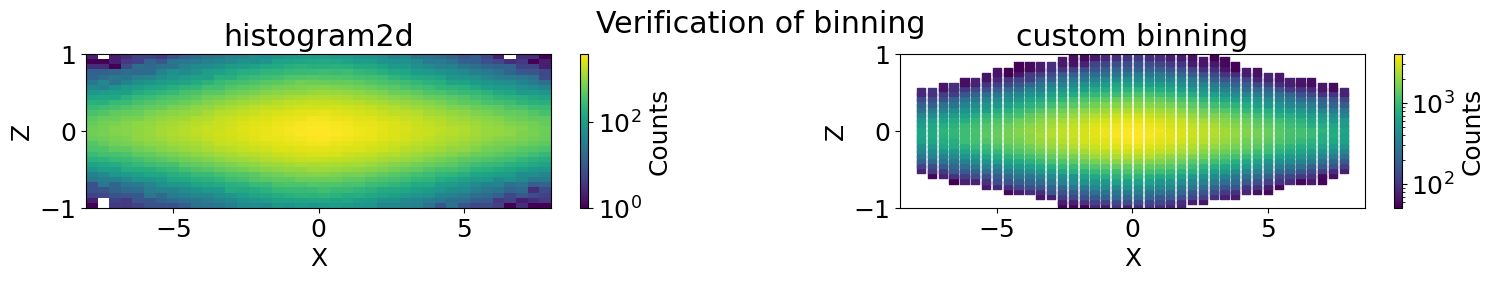

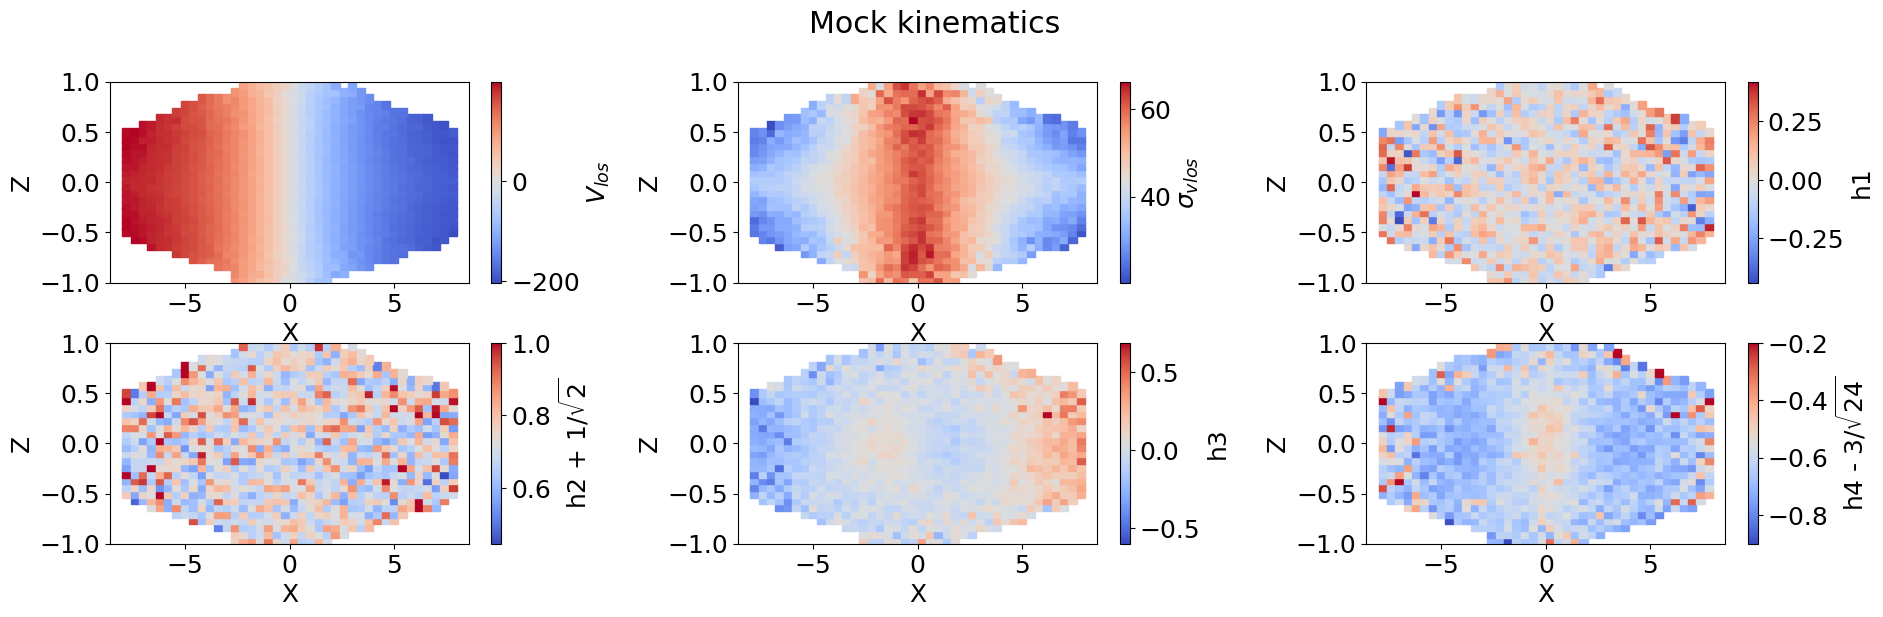

In [101]:
# nonempty_index_cut = np.array(nonempty_index)
nonempty_index_cut = np.argwhere(nonempty_index)[:,0]

fig, ax = plt.subplots(1,2,figsize=(18,2), gridspec_kw={'width_ratios': [1, 1], 'wspace':0.4})

fig.suptitle('Verification of binning', y=1.1)
H, xedge, yedge = np.histogram2d(x, z, bins=[X_edge, Y_edge])
im = ax[0].imshow(H.T, origin='lower', extent=[X_edge[0], X_edge[-1], Y_edge[0], Y_edge[-1]], aspect='auto', norm = 'log')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Z')
ax[0].set_title('histogram2d')
fig.colorbar(im, ax=ax[0], label='Counts')

im = ax[1].scatter(df_XY['X_grid'].values[nonempty_index_cut], df_XY['Y_grid'].values[nonempty_index_cut], c=df_XY['N_count'].values[nonempty_index_cut], 
                   cmap='viridis', s=35, marker = 's', norm = 'log')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Z')
ax[1].set_title('custom binning')
ax[1].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[1], label='Counts')

fig, ax = plt.subplots(2,3,figsize=(22,6), gridspec_kw={'wspace':0.4, 'hspace':0.3})
im = ax[0,0].scatter(df_XY['X_grid'].values[nonempty_index_cut], df_XY['Y_grid'].values[nonempty_index_cut], c=df_XY['V_mean'].values[nonempty_index_cut],
                      s=35, marker = 's', cmap='coolwarm')
ax[0,0].set_xlabel('X')
ax[0,0].set_ylabel('Z')
ax[0,0].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[0,0], label='$V_{los}$')

im = ax[0,1].scatter(df_XY['X_grid'].values[nonempty_index_cut], df_XY['Y_grid'].values[nonempty_index_cut], c=df_XY['V_sigma'].values[nonempty_index_cut], s=35, marker = 's', cmap='coolwarm')
ax[0,1].set_xlabel('X')
ax[0,1].set_ylabel('Z')
ax[0,1].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[0,1], label='$\sigma_{vlos}$')

im = ax[0,2].scatter(df_XY['X_grid'].values[nonempty_index_cut], df_XY['Y_grid'].values[nonempty_index_cut], c=df_XY['h1'].values[nonempty_index_cut], s=35, marker = 's', cmap='coolwarm')
ax[0,2].set_xlabel('X')
ax[0,2].set_ylabel('Z')
ax[0,2].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[0,2], label='h1')

im = ax[1,0].scatter(df_XY['X_grid'].values[nonempty_index_cut], df_XY['Y_grid'].values[nonempty_index_cut], c=df_XY['h2'].values[nonempty_index_cut] + 1/np.sqrt(2), s=35, marker = 's', cmap='coolwarm', vmax = 1)
ax[1,0].set_xlabel('X')
ax[1,0].set_ylabel('Z')
ax[1,0].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[1,0], label='h2 + 1/$\sqrt{2}$')

im = ax[1,1].scatter(df_XY['X_grid'].values[nonempty_index_cut], df_XY['Y_grid'].values[nonempty_index_cut], c=df_XY['h3'].values[nonempty_index_cut], s=35, marker = 's', cmap='coolwarm')
ax[1,1].set_xlabel('X')
ax[1,1].set_ylabel('Z')
ax[1,1].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[1,1], label='h3')

im = ax[1,2].scatter(df_XY['X_grid'].values[nonempty_index_cut], df_XY['Y_grid'].values[nonempty_index_cut], c=df_XY['h4'].values[nonempty_index_cut] - 3/np.sqrt(24), s=35, marker = 's', cmap='coolwarm', vmax = -0.2)
ax[1,2].set_xlabel('X')
ax[1,2].set_ylabel('Z')
ax[1,2].set(ylim=(Y_min,Y_max))
fig.colorbar(im, ax=ax[1,2], label='h4 - 3/$\sqrt{24}$')

fig.suptitle('Mock kinematics', y=1.0)

print('|h1-4| max:', jnp.max(jnp.fabs(df_XY['h1'].values[nonempty_index_cut])), 
jnp.max(jnp.fabs(df_XY['h2'].values[nonempty_index_cut])), 
jnp.max(jnp.fabs(df_XY['h3'].values[nonempty_index_cut])), 
jnp.max(jnp.fabs(df_XY['h4'].values[nonempty_index_cut])))

## new logL and pipeline below

In [2]:

@jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val

@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).
    
    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)
    
    # --- Step 1: Compute Sigma_z (Vertical Integration) ---
    
    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)
    
    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
    
    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0
    
    sigma_z2 = (1.0 / nu_val) * integral_val
    
    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)
    
    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)
    
    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR
    
    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)
        
        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)
    
    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)
    
    v_phi_total_sq = term1 + term2 + term3
    
    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R
    
    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))
    
    return output


@jax.jit
def _nll_z(z, 
            A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, 
            y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
            sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2):

    x = jnn.softplus(z)  # strictly positive
    # jax.debug.print("A_Rzphi's shape: {x_norm}", x_norm=A_Rzphi.shape)
    # jax.debug.print("x's shape: {x_norm}", x_norm=x.shape)
    r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi

    density_2DXY = A_xy @ x
    r_2dXY = (density_2DXY - y_xy) / sig_xy

    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    r_h1 = ( (A_h1 @ x) / y_xy - y_h1 ) / sig_A1
    r_h2 = ( (A_h2 @ x) / y_xy - y_h2 ) / sig_A2
    r_h3 = ( (A_h3 @ x) / y_xy - y_h3 ) / sig_A3
    r_h4 = ( (A_h4 @ x) / y_xy - y_h4 ) / sig_A4

    val1 = 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi)
    val2 = 0.5 * jnp.dot(r_2dXY, r_2dXY)
    val3 = 0.5 * jnp.dot(r_h1, r_h1)
    val4 = 0.5 * jnp.dot(r_h2, r_h2)
    val5 = 0.5 * jnp.dot(r_h3, r_h3)
    val6 = 0.5 * jnp.dot(r_h4, r_h4)

    return val1 + val2 + val3 + val4 + val5 + val6 + 0.5 * l2 * jnp.dot(x, x)#
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                        y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                        sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                        l2=1e-3, maxiter=1000, tol=1e-6):
    z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, 
                    A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat


@jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 2500
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        jnp.array([[0,10.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-8.,8.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = Nxy.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    A_h1 = jnp.where(jnp.fabs(A_h1)>2, 0.0, A_h1)
    A_h2 = jnp.where(jnp.fabs(A_h2)>2, -1/np.sqrt(2), A_h2)
    A_h3 = jnp.where(jnp.fabs(A_h3)>2, 0.0, A_h3)
    A_h4 = jnp.where(jnp.fabs(A_h4)>2, 3/np.sqrt(24), A_h4)

    y_Rzphi = dict_data['Rzphi_density_data'].astype(jnp.float32)
    y_xy = dict_data['XY_density_data'].astype(jnp.float32)
    y_h1 = dict_data['h1_data'].astype(jnp.float32)
    y_h2 = dict_data['h2_data'].astype(jnp.float32)
    y_h3 = dict_data['h3_data'].astype(jnp.float32)
    y_h4 = dict_data['h4_data'].astype(jnp.float32)

    sig_Rzphi = 0.02 * y_Rzphi + 1.0
    sig_xy = 0.01 * y_xy + 1.0
    # frac_err_min = 0.1
    h_err_min = 0.05
    sig_A1 = jnp.where(h_err_min > dict_data['h1_data_err'], h_err_min, dict_data['h1_data_err']) + EPSILON
    sig_A2 = jnp.where(h_err_min > dict_data['h2_data_err'], h_err_min, dict_data['h2_data_err']) + EPSILON
    sig_A3 = jnp.where(h_err_min > dict_data['h3_data_err'], h_err_min, dict_data['h3_data_err']) + EPSILON
    sig_A4 = jnp.where(h_err_min > dict_data['h4_data_err'], h_err_min, dict_data['h4_data_err']) + EPSILON

    non_empty_index = dict_data['non_empty_index']
    y_xy = y_xy[non_empty_index]
    A_xy = A_xy[non_empty_index,:]
    sig_xy = sig_xy[non_empty_index]
    y_h1 = y_h1[non_empty_index]
    A_h1 = A_h1[non_empty_index,:]
    sig_A1 = sig_A1[non_empty_index]
    y_h2 = y_h2[non_empty_index]
    A_h2 = A_h2[non_empty_index,:]
    sig_A2 = sig_A2[non_empty_index]
    y_h3 = y_h3[non_empty_index]
    A_h3 = A_h3[non_empty_index,:]
    sig_A3 = sig_A3[non_empty_index]
    y_h4 = y_h4[non_empty_index]
    A_h4 = A_h4[non_empty_index,:]
    sig_A4 = sig_A4[non_empty_index]

    v0 = v0[non_empty_index]
    s = s[non_empty_index]

    renormalise_Rzphi = jnp.amax(y_Rzphi)
    renormalise_xy = jnp.amax(y_xy)
    renormalise_h1 = jnp.amax(jnp.fabs(y_h1))
    renormalise_h2 = jnp.amax(jnp.fabs(y_h2))
    renormalise_h3 = jnp.amax(jnp.fabs(y_h3))
    renormalise_h4 = jnp.amax(jnp.fabs(y_h4))

    y_xy = y_xy / renormalise_xy
    A_xy = A_xy / renormalise_xy
    sig_xy = sig_xy / renormalise_xy
    y_Rzphi = y_Rzphi / renormalise_Rzphi
    A_Rzphi = A_Rzphi / renormalise_Rzphi
    sig_Rzphi = sig_Rzphi / renormalise_Rzphi
    y_h1 = y_h1 / renormalise_h1
    A_h1 = A_h1 / renormalise_h1
    sig_A1 = sig_A1 / renormalise_h1
    y_h2 = y_h2 / renormalise_h2
    A_h2 = A_h2 / renormalise_h2
    sig_A2 = sig_A2 / renormalise_h2
    y_h3 = y_h3 / renormalise_h3
    A_h3 = A_h3 / renormalise_h3
    sig_A3 = sig_A3 / renormalise_h3
    y_h4 = y_h4 / renormalise_h4
    A_h4 = A_h4 / renormalise_h4
    sig_A4 = sig_A4 / renormalise_h4

    # print("N_xy data nan:",jnp.isnan(y_xy).sum())
    # print("N_xy data non zero:",(y_xy!=0).sum())
    # print('sigma_xy nan:',jnp.isnan(sig_xy).sum())
    # print('sigma_xy non zero:',(sig_xy!=0).sum())
    # print("h1 data nan:",jnp.isnan(y_h1).sum())
    # print("h1 data non zero:",(y_h1!=0).sum())
    # print("sigma_h1 nan:",jnp.isnan(sig_A1).sum())
    # print("sigma_h1 non zero:",(sig_A1!=0).sum())
    # print("h2 data nan:",jnp.isnan(y_h2).sum())
    # print("h2 data non zero:",(y_h2!=0).sum())
    # print("sigma_h2 nan:",jnp.isnan(sig_A2).sum())
    # print("sigma_h2 non zero:",(sig_A2!=0).sum())
    # print("h3 data nan:",jnp.isnan(y_h3).sum())
    # print("h3 data non zero:",(y_h3!=0).sum())
    # print("sigma_h3 nan:",jnp.isnan(sig_A3).sum())
    # print("sigma_h3 non zero:",(sig_A3!=0).sum())
    # print("h4 data nan:",jnp.isnan(y_h4).sum())
    # print("h4 data non zero:",(y_h4!=0).sum())
    # print("sigma_h4 nan:",jnp.isnan(sig_A4).sum())
    # print("sigma_h4 non zero:",(sig_A4!=0).sum())
    
    weights = solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
                                    l2=1e-3, maxiter=500)

    # weights = jnn.softplus(weights)

    #===================================== Calculate the net kinematics of the model =========================================


    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    density_2DXY = A_xy @ weights
    h1_model = (A_h1 @ weights) / density_2DXY
    h2_model = (A_h2 @ weights) / density_2DXY
    h3_model = (A_h3 @ weights) / density_2DXY
    h4_model = (A_h4 @ weights) / density_2DXY

    V_model, sigma_model = h_to_V_sigma(h1_model, h2_model, v0, s)
    

    return V_model, sigma_model, h3_model, h4_model, weights


@jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    V_model, sigma_model, h3_model, h4_model, weights = model(params_halo_pot, params_disk_rho, dict_data)

    # jax.debug.print("`V_model` shape: {x_norm}", x_norm=V_model.shape)
    # jax.debug.print("V_model with nan: {x_norm}", x_norm=jnp.isnan(V_model).sum())
    # jax.debug.print("`V_model`: {x_norm}", x_norm=V_model)
    # jax.debug.print("`sigma_model`: {x_norm}", x_norm=sigma_model)
    # jax.debug.print("`weights`: {x_norm}", x_norm=weights)
    # jax.debug.print("`weights 16th`: {x_norm}", x_norm=jnp.percentile(weights, 16))
    # jax.debug.print("`weights 84th`: {x_norm}", x_norm=jnp.percentile(weights, 84))
    # jax.debug.print("weights with nan: {x_norm}", x_norm=jnp.isnan(weights).sum())

    V_model = jnp.where(jnp.isnan(V_model), 0.0, V_model)
    sigma_model = jnp.where(jnp.isnan(sigma_model), 0.0, sigma_model)
    h3_model = jnp.where(jnp.isnan(h3_model), 0.0, h3_model)
    h4_model = jnp.where(jnp.isnan(h4_model), 0.0, h4_model)

    V_data, V_data_err = dict_data['V_data'], dict_data['V_data_err']
    sigma_data, sigma_data_err = dict_data['sigma_data'], dict_data['sigma_data_err']
    h3_data, h3_data_err = dict_data['h3_data'], dict_data['h3_data_err']
    h4_data, h4_data_err = dict_data['h4_data'], dict_data['h4_data_err']

    non_empty_index = dict_data['non_empty_index']
    V_data = V_data[non_empty_index]
    V_data_err = V_data_err[non_empty_index]
    sigma_data = sigma_data[non_empty_index]
    sigma_data_err = sigma_data_err[non_empty_index]
    h3_data = h3_data[non_empty_index]
    h3_data_err = h3_data_err[non_empty_index]
    h4_data = h4_data[non_empty_index]
    h4_data_err = h4_data_err[non_empty_index]

    # jax.debug.print("V diff mean sigma_model: {x_norm}, {sigma}", 
    #                 x_norm=jnp.nanmean(jnp.fabs(V_model - V_data)), sigma=jnp.nanstd(jnp.fabs(V_model - V_data)))
    
    # jax.debug.print("sigma diff mean sigma_model: {x_norm}, {sigma}", 
    #                 x_norm=jnp.nanmean(jnp.fabs(sigma_model - sigma_data)), sigma=jnp.nanstd(jnp.fabs(sigma_model - sigma_data)))
    
    # jax.debug.print("h3 diff mean sigma_model: {x_norm}, {sigma}", 
    #                 x_norm=jnp.nanmean(jnp.fabs(h3_model - h3_data)), sigma=jnp.nanstd(jnp.fabs(h3_model - h3_data)))
    
    # jax.debug.print("h4 diff mean sigma_model: {x_norm}, {sigma}", 
    #                 x_norm=jnp.nanmean(jnp.fabs(h4_model - h4_data)), sigma=jnp.nanstd(jnp.fabs(h4_model - h4_data)))


    # frac_err_min = 0.1
    h_err_min = 0.05
    V_err_min = 10
    sigma_err_min = 5
    V_data_err = jnp.where(V_err_min > V_data_err, V_err_min, V_data_err)
    sigma_data_err = jnp.where(sigma_err_min > sigma_data_err, sigma_err_min, sigma_data_err)
    h3_data_err = jnp.where(h_err_min > h3_data_err, h_err_min, h3_data_err)
    h4_data_err = jnp.where(h_err_min > h4_data_err, h_err_min, h4_data_err)
    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((V_model - V_data)**2) / (V_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((sigma_model - sigma_data)**2) / (sigma_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((h3_model - h3_data)**2) / (h3_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((h4_model - h4_data)**2) / (h4_data_err + 1e-3)**2 )

    return log_likelihood

In [3]:
with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)

non_empty_index = jnp.where(df_XY_data['nonempty'].to_numpy())[0]
# non_empty_index = jnp.array(df_XY_data['nonempty'].to_numpy())



dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'non_empty_index': non_empty_index
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}


logL = logl(ground_truth, dict_data)
print(logL)

10000
-7991.9883


In [30]:
-1968892.2

-1968892.2

In [4]:
from tqdm import tqdm

N = 20
for i in tqdm(range (0, N)):

  dict_param = {
          'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
          'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
          'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
          'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
          'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
  }

  logL = logl(dict_param, dict_data)
  print(logL)

  5%|▌         | 1/20 [01:22<26:13, 82.79s/it]

-16889.674


 10%|█         | 2/20 [02:28<21:48, 72.70s/it]

-16529.078


 15%|█▌        | 3/20 [04:00<23:03, 81.41s/it]

...

-4972.556


 95%|█████████▌| 19/20 [29:50<01:33, 93.64s/it]

-5971.04


100%|██████████| 20/20 [31:28<00:00, 94.44s/it]

-6888.8037


# Draw voronoi bins

# Third pipeline 2026/01/28
### (add Voronoi binning)

In [1]:
%load_ext autoreload
%autoreload 2

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

path = '/home/hz420/python_script/SchwarMAX/'

<>:215: SyntaxWarning: invalid escape sequence '\s'
<>:216: SyntaxWarning: invalid escape sequence '\s'
<>:215: SyntaxWarning: invalid escape sequence '\s'
<>:216: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_659716/1694948432.py:215: SyntaxWarning: invalid escape sequence '\s'
  fig1.colorbar(cb3, ax=ax1[0,2], label='$\sigma_V$ [km/s]')
/tmp/ipykernel_659716/1694948432.py:216: SyntaxWarning: invalid escape sequence '\s'
  ax1[0,2].set_title('$\sigma_V$')


Total counts in XY bins: 2400 and only 1 per bin: True
Bin-accretion Delaunay...
1077  initial bins.
1051  good bins.
Regularization...
Bins: 1051; Single Pixels: 728/2400
Capacity Fractional RMS Scatter (%): 26.53
Time Accretion: 0.10 s
Time Regularization (it=7): 0.09 s
[   0    1    2 ... 1048 1049 1050] [ 1  1  1 ... 20 32 21]


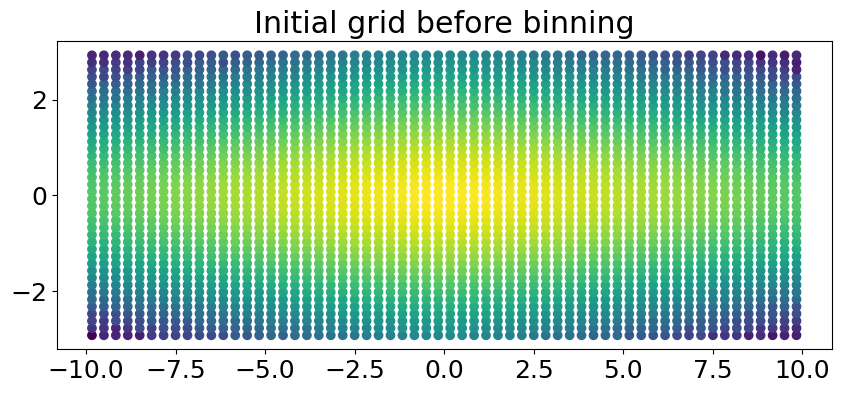

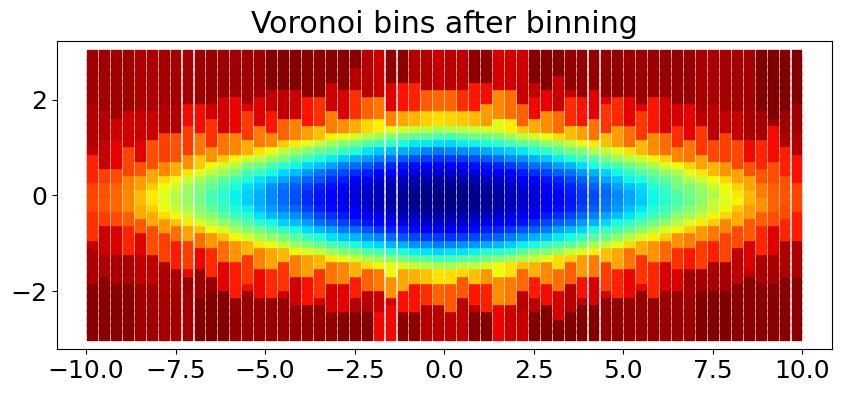

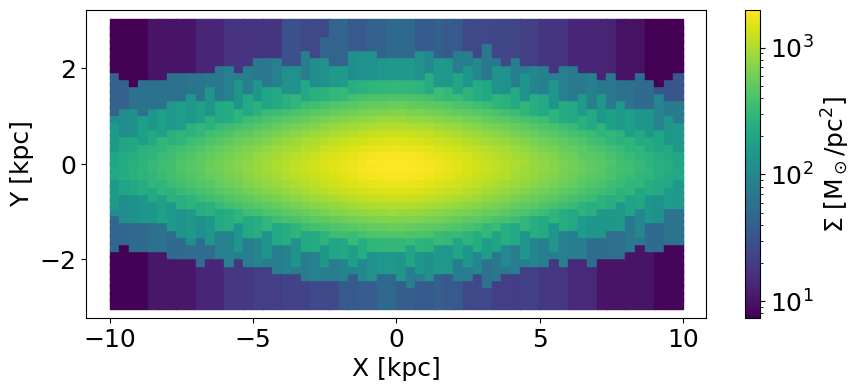

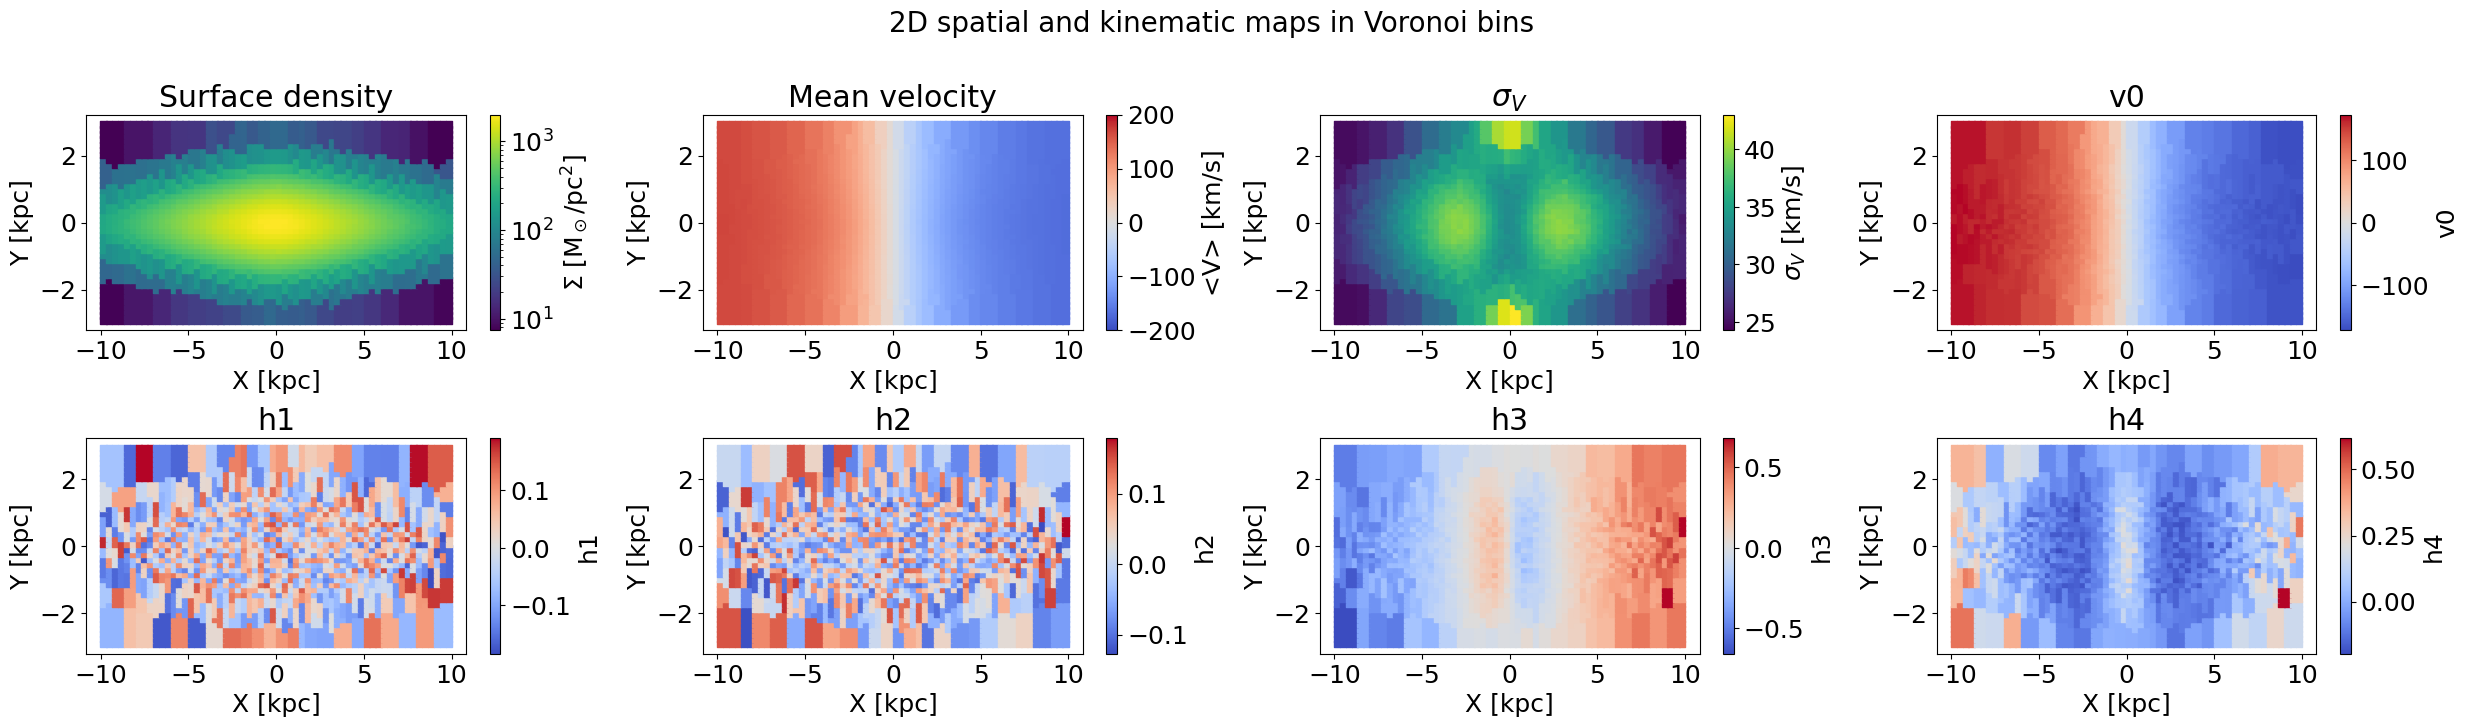

In [4]:
# Load data
import numpy as np
import matplotlib.pyplot as plt
from powerbin import PowerBin
import pickle
import jax
import pandas as pd

with open('/data/hz420-2/SchwarMAX/mock_axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = np.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
mass_data = data['mass']

x, y = w0_data[:, 0], w0_data[:, 1]
R, phi = np.sqrt(w0_data[:, 0]**2 + w0_data[:, 1]**2), np.arctan2(w0_data[:, 1], w0_data[:, 0])
z, vy = w0_data[:, 2], w0_data[:, 4]

x = np.random.normal(x, 0., size=x.shape)
y = np.random.normal(y, 0., size=y.shape)
z = np.random.normal(z, 0., size=z.shape)

Rzphi_stars = np.stack([R, z, phi], axis=-1)
XY_stars = np.stack([x, z], axis=-1) # prefect edge-on view

# signal, xedge, yedge = np.histogram2d(XY_stars[:, 0], XY_stars[:, 1], bins=[80, 80], range=[[-10.,10.],[-1.5,1.5]])
# noise = np.sqrt(signal+1)

# xmid, ymid = 0.5 * (xedge[1:] + xedge[:-1]), 0.5 * (yedge[1:] + yedge[:-1])
# xgrid, ygrid = np.meshgrid(xmid, ymid, indexing='ij')
# signal = signal.flatten()

# mask = signal >= 0
# signal = signal[mask]
# noise = noise.flatten()[mask]
# XY_coords = np.column_stack([xgrid.flatten(), ygrid.flatten()])[mask]


X_min, X_max = -10., 10.
Y_min, Y_max = -3., 3.
nX, nY = 60,40
area_XY = ((X_max - X_min)/nX) * ((Y_max - Y_min)/nY)

X_edge = jnp.linspace(X_min, X_max, nX+1)
Y_edge = jnp.linspace(Y_min, Y_max, nY+1)
X_mids, Y_mids = 0.5 * (X_edge[:-1] + X_edge[1:]), 0.5 * (Y_edge[:-1] + Y_edge[1:])

X_mid_mesh, Y_mids_mesh = jnp.meshgrid(X_mids, Y_mids, indexing='ij')
XY_mid_grid = jnp.stack([X_mid_mesh.ravel(), Y_mids_mesh.ravel()], axis=-1)  # (n_X*n_Y, 2)

XY_minmax=jnp.array([[X_min,X_max],[Y_min,Y_max]])
nXY=jnp.array([nX,nY])
num_segments_XY=nXY.prod()
XY_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_grid_indices = assign_regular_grid(XY_mid_grid,
                                    grid_min=XY_minmax[:,0],
                                    grid_max=XY_minmax[:,1],
                                    n_bins=nXY,
                                    strides=XY_strides)
_, COUNTS_XY = jnp.unique(XY_grid_indices, return_counts=True)
print('Total counts in XY bins:', jnp.sum(COUNTS_XY), 'and only 1 per bin:', jnp.all(COUNTS_XY <= 1))

df_XY = pd.DataFrame({
    'id': XY_grid_indices,
    'X_grid': XY_mid_grid[:,0],
    'Y_grid': XY_mid_grid[:,1],
})

XY_strdides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nXY[:-1])])
XY_indices = assign_regular_grid(XY_stars,
                                grid_min=XY_minmax[:,0],
                                grid_max=XY_minmax[:,1],
                                n_bins=nXY,
                                strides=XY_strdides)

index = jnp.arange(num_segments_XY)
counts = jax.ops.segment_sum(jnp.ones_like(vy), XY_indices, num_segments=num_segments_XY)
signal = counts + 1
noise = np.sqrt(signal + 1)

df_XY_signal = pd.DataFrame({
    'id': index,
    'signal': signal,
    'noise': noise
})
df_XY_merged = df_XY.merge(df_XY_signal, on='id', how='left')

XY_coords = df_XY_merged[['X_grid', 'Y_grid']].to_numpy()
signal = df_XY_merged['signal'].to_numpy()
noise = df_XY_merged['noise'].to_numpy()

# H, xedge, yedge = np.histogram2d(XY_stars[:, 0], XY_stars[:, 1], bins=[X_edge, Y_edge])
# signal = H.flatten()
# noise = np.sqrt(signal + 1)
# xmid, ymid = 0.5 * (xedge[1:] + xedge[:-1]), 0.5 * (yedge[1:] + yedge[:-1])
# xgrid, ygrid = np.meshgrid(xmid, ymid, indexing='ij')
# XY_coords = np.column_stack([xgrid.flatten(), ygrid.flatten()])

mask = signal > 0
XY_coords = XY_coords[mask]
signal = signal[mask]
noise = noise[mask]

target_sn = 75
def capacity_spec(index):
    """Calculates (S/N)^2 for a bin from its pixel indices."""
    # Standard S/N formula for uncorrelated noise
    sn = np.sum(signal[index]) / np.sqrt(np.sum(noise[index]**2))
    # Example for correlated noise (see full example file for details):
    # sn /= 1 + 1.07 * np.log10(len(index))
    return sn**2

# Perform the binning. The target is target_sn**2 to match the capacity definition.
pow = PowerBin(XY_coords, capacity_spec, target_capacity=target_sn**2, regul = True, maxiter=10000)

bin_index_remap = pow.bin_num

plt.figure(figsize=(10,4))
plt.scatter(XY_coords[:, 0], XY_coords[:, 1], c=signal, cmap='viridis', norm='log')
plt.title('Initial grid before binning')
# plt.scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c=df_XY_merged['signal'], s = 50, marker = 's')

plt.figure(figsize=(10,4))
plt.scatter(XY_coords[:, 0], XY_coords[:, 1], c=bin_index_remap, s = 50, cmap='jet', marker = 's')
plt.title('Voronoi bins after binning')

# import jax.numpy as jnp

# colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'black', 'navy', 'lime']
# colors_ls = np.vstack([colors]*100).flatten()
# plt.figure(figsize=(10,4))
# for i in range (np.amax(bin_index_remap)):
#     bin_coords = XY_coords[bin_index_remap == i]
#     plt.scatter(bin_coords[:, 0], bin_coords[:, 1], s = 30,  marker = 's', color=colors_ls[i])

df_XY_merged['Vbin_index'] = bin_index_remap
# df_XY_merged['npix_per_Vbin'] = pow.npix

df_XY_merged = df_XY_merged.sort_values('id') # Very important step !!!

_bin_index_remap = df_XY_merged['Vbin_index'].to_numpy()
_bin_index_remap = jnp.append(_bin_index_remap, -1) # for safety if some stars fall outside the grid, it will be assigned to -1 and ignored

Vbin_index, num_per_bin = np.unique(_bin_index_remap, return_counts=True)
Vbin_index, num_per_bin = Vbin_index[Vbin_index!=-1], num_per_bin[Vbin_index!=-1] # remove the -1 bin
print(Vbin_index, num_per_bin)

XY_Vbin_index = _bin_index_remap[XY_indices]
mass_in_Vbin = jax.ops.segment_sum(mass_data, XY_Vbin_index, num_segments=np.amax(_bin_index_remap)+1)
rho_in_Vbin = mass_in_Vbin / (num_per_bin * area_XY * 1e6) # units: M_sun / pc^2

df_XY_merged['rho_in_Vbin'] = rho_in_Vbin[df_XY_merged['Vbin_index'].to_numpy()]

fig, ax = plt.subplots(figsize=(10,4))
cb = ax.scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c=df_XY_merged['rho_in_Vbin'], 
                s = 50, cmap='viridis', marker = 's', norm = 'log')
fig.colorbar(cb, ax=ax, label=r'$\Sigma$ [M$_\odot$/pc$^2$]')
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')


# Create mock data in voronoi bins

mass_tot = jax.ops.segment_sum(mass_data, XY_Vbin_index, num_segments=np.amax(_bin_index_remap)+1)
V_mean = jax.ops.segment_sum(mass_data * vy, XY_Vbin_index, num_segments=np.amax(_bin_index_remap)+1) / (mass_tot + EPSILON)
V2_mean = jax.ops.segment_sum(mass_data * vy**2, XY_Vbin_index, num_segments=np.amax(_bin_index_remap)+1) / (mass_tot + EPSILON)
V_sigma = jnp.sqrt(jnp.clip(V2_mean - V_mean**2, a_min=0.0))

v0 = V_mean + jnp.array(np.random.uniform(-5., 5., size=V_mean.shape))
s = V_sigma + jnp.array(np.random.uniform(-3., 3., size=V_sigma.shape))
s = jnp.where(s < 20.0, 20.0, s)
v0_cell = v0[XY_Vbin_index]
s_cell = s[XY_Vbin_index]

w = (vy - v0_cell) / s_cell # (v_los - v0) / s, where in edge-on case v_los = vy = wN[:,4]
counts = jax.ops.segment_sum(jnp.ones_like(vy), XY_Vbin_index, num_segments=np.amax(_bin_index_remap)+1)
sum_w1 = jax.ops.segment_sum(w, XY_Vbin_index, num_segments=np.amax(_bin_index_remap)+1)
sum_w2 = jax.ops.segment_sum(w**2, XY_Vbin_index, num_segments=np.amax(_bin_index_remap)+1)
sum_w3 = jax.ops.segment_sum(w**3, XY_Vbin_index, num_segments=np.amax(_bin_index_remap)+1)
sum_w4 = jax.ops.segment_sum(w**4, XY_Vbin_index, num_segments=np.amax(_bin_index_remap)+1)
eps = EPSILON
norm = counts + eps
w1 = sum_w1 / norm
w2 = sum_w2 / norm
w3 = sum_w3 / norm
w4 = sum_w4 / norm

h1 = w1
h2 = ((w2 - 1) / jnp.sqrt(2))
h3 = ((w3 - 3 * w1) / jnp.sqrt(6))
h4 = ((w4 - 6 * w2 + 3) / jnp.sqrt(24))

df_XY_merged['V_mean'] = V_mean[df_XY_merged['Vbin_index'].to_numpy()]
df_XY_merged['V_sigma'] = V_sigma[df_XY_merged['Vbin_index'].to_numpy()]
df_XY_merged['h1'] = h1[df_XY_merged['Vbin_index'].to_numpy()]
df_XY_merged['h2'] = h2[df_XY_merged['Vbin_index'].to_numpy()]
df_XY_merged['h3'] = h3[df_XY_merged['Vbin_index'].to_numpy()]
df_XY_merged['h4'] = h4[df_XY_merged['Vbin_index'].to_numpy()]

fig1,ax1 = plt.subplots(2,4,figsize=(30,7), gridspec_kw={'hspace':0.5, 'wspace':0.3})
fig1.suptitle('2D spatial and kinematic maps in Voronoi bins', fontsize=20, y = 1.03)
cb1 = ax1[0,0].scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c=df_XY_merged['rho_in_Vbin'], 
                s = 20, cmap='viridis', marker = 's', norm = 'log')
fig1.colorbar(cb1, ax=ax1[0,0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')
ax1[0,0].set_title('Surface density')
ax1[0,0].set_xlabel('X [kpc]')
ax1[0,0].set_ylabel('Y [kpc]')
cb2 = ax1[0,1].scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c=df_XY_merged['V_mean'], 
                s = 20, cmap='coolwarm', marker = 's', vmin = -200, vmax=200)
fig1.colorbar(cb2, ax=ax1[0,1], label='<V> [km/s]')
ax1[0,1].set_title('Mean velocity')
ax1[0,1].set_xlabel('X [kpc]')
ax1[0,1].set_ylabel('Y [kpc]')
cb3 = ax1[0,2].scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c=df_XY_merged['V_sigma'], 
                s = 20, cmap='viridis', marker = 's')
fig1.colorbar(cb3, ax=ax1[0,2], label='$\sigma_V$ [km/s]')
ax1[0,2].set_title('$\sigma_V$')
ax1[0,2].set_xlabel('X [kpc]')
ax1[0,2].set_ylabel('Y [kpc]')

cb4 = ax1[1,0].scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c=df_XY_merged['h1'],
                s = 20, cmap='coolwarm', marker = 's')
fig1.colorbar(cb4, ax=ax1[1,0], label='h1')
ax1[1,0].set_title('h1')
ax1[1,0].set_xlabel('X [kpc]')
ax1[1,0].set_ylabel('Y [kpc]')
cb5 = ax1[1,1].scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c=df_XY_merged['h2'],
                s = 20, cmap='coolwarm', marker = 's')
fig1.colorbar(cb5, ax=ax1[1,1], label='h2')
ax1[1,1].set_title('h2')
ax1[1,1].set_xlabel('X [kpc]')
ax1[1,1].set_ylabel('Y [kpc]')
cb6 = ax1[1,2].scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c=df_XY_merged['h3'],
                s = 20, cmap='coolwarm', marker = 's')
fig1.colorbar(cb6, ax=ax1[1,2], label='h3')
ax1[1,2].set_title('h3')
ax1[1,2].set_xlabel('X [kpc]')
ax1[1,2].set_ylabel('Y [kpc]')
cb7 = ax1[1,3].scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c=df_XY_merged['h4'],
                s = 20, cmap='coolwarm', marker = 's')
fig1.colorbar(cb7, ax=ax1[1,3], label='h4')
ax1[1,3].set_title('h4')
ax1[1,3].set_xlabel('X [kpc]')
ax1[1,3].set_ylabel('Y [kpc]')

cb7 = ax1[0,3].scatter(df_XY_merged['X_grid'], df_XY_merged['Y_grid'], c= v0[df_XY_merged['Vbin_index'].to_numpy()],
                s = 20, cmap='coolwarm', marker = 's')
fig1.colorbar(cb7, ax=ax1[0,3], label='v0')
ax1[0,3].set_title('v0')
ax1[0,3].set_xlabel('X [kpc]')
ax1[0,3].set_ylabel('Y [kpc]')

bin_dict = {
    'nX_nY': [nX, nY],
    'X_minmax': [X_min, X_max],
    'Y_minmax': [Y_min, Y_max],
    'X_regular_grid': df_XY_merged['X_grid'].to_numpy(),
    'Y_regular_grid': df_XY_merged['Y_grid'].to_numpy(),
    'bin_index': np.array(Vbin_index),
    'num_per_bin': np.array(num_per_bin),
    'voronoi_bins_xy':pow.xybin, # list of arrays, each array gives the XY coords of the pixels in that voronoi bin
    'total_bins': np.amax(_bin_index_remap)+1,
    'bin_mapping': np.array(_bin_index_remap), # length = nX*nY, mapping each XY grid to voronoi bin, order is the same as the uniform grid index (0-nX*nY),
    'surface_density': np.array(rho_in_Vbin), # length = number of voronoi bins
    'V_mean': np.array(V_mean),
    'V_sigma': np.array(V_sigma),
    'h1': np.array(h1),
    'h2': np.array(h2),
    'h3': np.array(h3),
    'h4': np.array(h4),
    'v0': np.array(v0),
    's': np.array(s),
}

# with open(path + 'mock_axisymmetric_disc_XY_voronoi.pkl', 'wb') as f:
#     pickle.dump(bin_dict, f)

In [326]:
R_min, R_max =0., 10.
z_min, z_max = -3, 3
n_R, n_z, n_phi =10, 6, 6

R_edge = jnp.linspace(R_min, R_max, n_R+1)
z_edge = jnp.linspace(z_min, z_max, n_z+1)
phi_edge = jnp.linspace(-jnp.pi, jnp.pi, n_phi+1)
R_mids, z_mids, phi_mids = 0.5 * (R_edge[:-1] + R_edge[1:]), 0.5 * (z_edge[:-1] + z_edge[1:]), 0.5 * (phi_edge[:-1] + phi_edge[1:])
dR, dz, dphi = R_edge[1]-R_edge[0], z_edge[1]-z_edge[0], phi_edge[1]-phi_edge[0]

R_mids_mesh, z_mids_mesh, phi_mids_mesh = jnp.meshgrid(R_mids, z_mids, phi_mids, indexing='ij')

Rzphi_mid_grid = jnp.stack([R_mids_mesh.ravel(), z_mids_mesh.ravel(), phi_mids_mesh.ravel()], axis=-1)  # (n_R*n_z*n_phi, 3)

# Get the central point of each bin
Rzphi_minmax=jnp.array([[R_min, R_max],[z_min, z_max],[-jnp.pi, jnp.pi]])
nRzphi=jnp.array([n_R,n_z,n_phi])
num_segments_Rzphi=nRzphi.prod()
Rzphi_strides = jnp.concatenate([jnp.array([1]), jnp.cumprod(nRzphi[:-1])])
Rzphi_grid_indices = assign_regular_grid(Rzphi_mid_grid,
                                    grid_min=Rzphi_minmax[:,0],
                                    grid_max=Rzphi_minmax[:,1],
                                    n_bins=nRzphi,
                                    strides=Rzphi_strides)
# Grid id of Rzphi_grid_indices has the corresponding center Rzphi_mid_grid
_, COUNTS = jnp.unique(Rzphi_grid_indices, return_counts=True)
print('Total counts in Rzphi bins:', jnp.sum(COUNTS), 'and only 1 per bin:', jnp.all(COUNTS <= 1))

df_Rzphi = pd.DataFrame({
    'id': Rzphi_grid_indices,
    'R_grid': Rzphi_mid_grid[:,0],
    'z_grid': Rzphi_mid_grid[:,1],
    'phi_grid': Rzphi_mid_grid[:,2],
})

Rzphi_indices = assign_regular_grid(Rzphi_stars,
                                    grid_min=Rzphi_minmax[:,0],
                                    grid_max=Rzphi_minmax[:,1],
                                    n_bins=nRzphi,
                                    strides=Rzphi_strides)
mass = jax.ops.segment_sum(mass_data, Rzphi_indices, num_segments=num_segments_Rzphi)
index = jnp.arange(num_segments_Rzphi)
df_counts_Rzphi = pd.DataFrame({
    'id': index,
    'mass': mass.astype(jnp.float32),
})
df_Rzphi = df_Rzphi.merge(df_counts_Rzphi, on='id', how='left')

df_Rzphi = df_Rzphi.sort_values('id') # Very important step !!!
# df_Rzphi.to_csv(path + 'mock_axisymmetric_disc_Rzphi.csv', index=False)

dict_Rzphi = {
    'id':df_Rzphi['id'].to_numpy(),
    'R_grid':df_Rzphi['R_grid'].to_numpy(),
    'z_grid':df_Rzphi['z_grid'].to_numpy(),
    'phi_grid':df_Rzphi['phi_grid'].to_numpy(),
    'mass': df_Rzphi['mass'].to_numpy(),
    'R_minmax': [R_min, R_max],
    'z_minmax': [z_min, z_max],
    'phi_minmax': [-jnp.pi, jnp.pi],
    'nR_nz_nphi': [n_R, n_z, n_phi],
}

with open(path + 'mock_axisymmetric_disc_Rzphi.pkl', 'wb') as f:
    pickle.dump(dict_Rzphi, f)

Total counts in Rzphi bins: 360 and only 1 per bin: True


# New logL

In [ ]:
@jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val

@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).

    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)

    # --- Step 1: Compute Sigma_z (Vertical Integration) ---

    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)

    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)

    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0

    sigma_z2 = (1.0 / nu_val) * integral_val

    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)

    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)

    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR

    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)

        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)

    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)

    v_phi_total_sq = term1 + term2 + term3

    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R

    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))

    return output


@jax.jit
def _nll_z(z, 
            A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, 
            y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
            sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2):

    x = jnn.softplus(z)  # strictly positive
    # x = jnp.exp(z)  # strictly positive
    # jax.debug.print("A_Rzphi's shape: {x_norm}", x_norm=A_Rzphi.shape)
    # jax.debug.print("x's shape: {x_norm}", x_norm=x.shape)
    r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi

    mass_tot = jnp.sum(y_Rzphi)
    N_orb = len(x)
    wi = ( mass_tot / N_orb ) * jnp.ones_like(x)

    density_2DXY = A_xy @ x
    r_2dXY = (density_2DXY - y_xy) / sig_xy

    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)

    y_h1_model = (A_h1 @ x) / y_xy
    y_h2_model = (A_h2 @ x) / y_xy
    y_h3_model = (A_h3 @ x) / y_xy
    y_h4_model = (A_h4 @ x) / y_xy

    clip_val = 10.0
    y_h1_model = jnp.where(y_h1_model > clip_val, clip_val, y_h1_model)
    y_h2_model = jnp.where(y_h2_model > clip_val, clip_val, y_h2_model)
    y_h3_model = jnp.where(y_h3_model > clip_val, clip_val, y_h3_model)
    y_h4_model = jnp.where(y_h4_model > clip_val, clip_val, y_h4_model)
    y_h1_model = jnp.where(y_h1_model < -clip_val, -clip_val, y_h1_model)
    y_h2_model = jnp.where(y_h2_model < -clip_val, -clip_val, y_h2_model)
    y_h3_model = jnp.where(y_h3_model < -clip_val, -clip_val, y_h3_model)
    y_h4_model = jnp.where(y_h4_model < -clip_val, -clip_val, y_h4_model)

    r_h1 = ( y_h1_model - y_h1 ) / sig_A1
    r_h2 = ( y_h2_model - y_h2 ) / sig_A2
    r_h3 = ( y_h3_model - y_h3 ) / sig_A3
    r_h4 = ( y_h4_model - y_h4 ) / sig_A4

    val1 = 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi) / len(r_3dRzphi) * 5
    val2 = 0.5 * jnp.dot(r_2dXY, r_2dXY) / len(r_2dXY) * 5
    val4 = 0.5 * jnp.dot(r_h1, r_h1) / len(r_h1)# * 5
    val5 = 0.5 * jnp.dot(r_h2, r_h2) / len(r_h2)# * 5
    val3 = 0.5 * jnp.dot(r_h3, r_h3) / len(r_h3)# * 5
    val6 = 0.5 * jnp.dot(r_h4, r_h4) / len(r_h4)# * 5

    x_renormalised = x / wi
    # regularisation_factor = (l2 / N_orb) * jnp.dot(x_renormalised, x_renormalised)
    regularisation_factor = (l2 / N_orb) * jnp.sum(x_renormalised * jnp.log(x_renormalised + EPSILON))

    # jax.debug.print("z={val1}", 
    #                 val1=z,)
    # jax.debug.print("NLL components: Rzphi={val1}, XY={val2}, h1={val3}, h2={val4}, h3={val5}, h4={val6}, reg={reg}, tot={tot}", 
    #                 val1=val1, val2=val2, val3=val3, val4=val4, val5=val5, val6=val6, reg=regularisation_factor, 
    #                 tot=val1 + val2 + val3 + val4 + val5 + val6 + regularisation_factor)


    return val1 + val2 + val3 + val4 + val5 + val6 + regularisation_factor
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                        y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                        sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                        l2=1, maxiter=500, tol=1e-6):
    
    # jax.debug.print("A_Rzphi shape: {x_norm}", x_norm=A_Rzphi.shape)
    # jax.debug.print("total mass in Rzphi data: {x_norm}", x_norm=jnp.sum(y_Rzphi))
    # jax.debug.print("initial guess: {x_norm}", x_norm=(jnp.sum(y_Rzphi) / A_Rzphi.shape[1]))
    z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype) * (jnp.sum(y_Rzphi) / A_Rzphi.shape[1])  # initial guess
    # z0 = jnp.zeros(A_Rzphi.shape[1], A_Rzphi.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, 
                    A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)
    x_hat = jnn.softplus(res.params)
    # x_hat = jnp.exp(res.params)
    x_hat = jax.lax.stop_gradient(x_hat)
    return x_hat

@jax.jit
def solve_two_stage(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                    l2=1, maxiter=300):
    
    # Stage 1: Fit density only
    def density_only_loss(z):
        x = jnn.softplus(z)
        r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi
        r_2dXY = (A_xy @ x - y_xy) / sig_xy
        return 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi) + 0.5 * jnp.dot(r_2dXY, r_2dXY)


    
    z0 = jnp.ones(A_Rzphi.shape[1]) * (jnp.sum(y_Rzphi) / A_Rzphi.shape[1])  # initial guess    
    # z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype) * (jnp.sum(y_Rzphi) / A_Rzphi.shape[1]) + (jax.random.normal(jax.random.PRNGKey(45678), (A_Rzphi.shape[1],)) * 0.5)
    solver1 = jaxopt.LBFGS(fun=density_only_loss, maxiter=maxiter//2, tol = 1e-3)
    res1 = solver1.run(z0)
    # x_hat = jnn.softplus(res1.params)

    # Stage 2: Refine with all constraints, starting from Stage 1 solution
    solver2 = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter//2, tol = 1e-3)
    res2 = solver2.run(res1.params, A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)

    x_hat = jnn.softplus(res2.params)
    return x_hat

from jaxopt import BoxOSQP
from functools import partial

# @partial(jax.jit, static_argnames=('maxiter',))
def solve_qp(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
             y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
             sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
             l2=1e-5, maxiter=500):
    """
    Quadratic programming for Schwarzschild modeling using BoxOSQP.
    """
    n_orbits = A_Rzphi.shape[1]

    # Linearized kinematic matrices
    A_h1_lin = (A_h1 * A_xy) / y_xy[:, None]
    A_h2_lin = (A_h2 * A_xy) / y_xy[:, None]
    A_h3_lin = (A_h3 * A_xy) / y_xy[:, None]
    A_h4_lin = (A_h4 * A_xy) / y_xy[:, None]

    # Stack all constraints
    A = jnp.vstack([
        A_Rzphi / sig_Rzphi[:, None],
        A_xy / sig_xy[:, None],
        A_h1_lin / sig_A1[:, None],
        A_h2_lin / sig_A2[:, None],
        A_h3_lin / sig_A3[:, None],
        A_h4_lin / sig_A4[:, None],
    ])

    y = jnp.concatenate([
        y_Rzphi / sig_Rzphi,
        y_xy / sig_xy,
        y_h1 / sig_A1,
        y_h2 / sig_A2,
        y_h3 / sig_A3,
        y_h4 / sig_A4,
    ])

    # QP matrices: min 0.5 * x^T Q x + c^T x
    Q = A.T @ A + l2 * jnp.eye(n_orbits)
    c = -A.T @ y

    # Constraint: l <= A_constraint @ x <= u
    # For x >= 0, use A_constraint = I, l = 0, u = inf
    A_constraint = jnp.eye(n_orbits)
    l = jnp.zeros(n_orbits)
    u = jnp.full(n_orbits, jnp.inf)

    qp = BoxOSQP(maxiter=maxiter, tol=1e-3)
    sol = qp.run(params_obj=(Q, c), params_eq=A_constraint, params_ineq=(l, u)).params

    return sol.primal[0]

from functools import partial

# @partial(jax.jit, static_argnames=('maxiter',))
def solve_fista(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                l2=1e-5, maxiter=2000):
    """
    FISTA for non-negative least squares.

    Solves: min 0.5 * ||A @ x - y||^2 + 0.5 * l2 * ||x||^2
            s.t. x >= 0
    """
    n_orbits = A_Rzphi.shape[1]

    # Linearized kinematic matrices
    A_h1_lin = (A_h1 * A_xy) / y_xy[:, None]
    A_h2_lin = (A_h2 * A_xy) / y_xy[:, None]
    A_h3_lin = (A_h3 * A_xy) / y_xy[:, None]
    A_h4_lin = (A_h4 * A_xy) / y_xy[:, None]

    # Stack all constraints
    A = jnp.vstack([
        A_Rzphi / sig_Rzphi[:, None],
        A_xy / sig_xy[:, None],
        A_h1_lin / sig_A1[:, None],
        A_h2_lin / sig_A2[:, None],
        A_h3_lin / sig_A3[:, None],
        A_h4_lin / sig_A4[:, None],
    ])

    y = jnp.concatenate([
        y_Rzphi / sig_Rzphi,
        y_xy / sig_xy,
        y_h1 / sig_A1,
        y_h2 / sig_A2,
        y_h3 / sig_A3,
        y_h4 / sig_A4,
    ])

    # Precompute normal equations
    AtA = A.T @ A + l2 * jnp.eye(n_orbits)
    Aty = A.T @ y

    # Lipschitz constant
    L = jnp.linalg.norm(AtA, ord=2)
    step_size = 1.0 / L

    def fista_step(carry, _):
        x, x_old, t = carry

        # Gradient step
        grad = AtA @ x - Aty
        x_new = jnp.clip(x - step_size * grad, 0, None)

        # FISTA momentum
        t_new = (1 + jnp.sqrt(1 + 4 * t**2)) / 2
        x_accel = jnp.clip(x_new + ((t - 1) / t_new) * (x_new - x_old), 0, None)

        return (x_accel, x_new, t_new), None

    x0 = jnp.ones(n_orbits) / n_orbits
    (x_final, _, _), _ = jax.lax.scan(fista_step, (x0, x0, 1.0), None, length=maxiter)

    return x_final

# @jax.jit
@partial(jax.jit, static_argnames=('num_Vbin'))
def model(params_halo_pot, params_disk_rho, dict_data, num_Vbin):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']
    num_per_bin = dict_data['num_per_bin']
    bin_mapping = dict_data['bin_mapping']
    # num_Vbin = dict_data['total_bins']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    # g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    g1, g2, g3 = (jax.random.uniform(key1, (n_particles,))-0.5)*2, (jax.random.uniform(key2, (n_particles,))-0.5)*2, (jax.random.uniform(key3, (n_particles,))-0.5)*2
    vR = g1 * sig_R * 2 # 2 sigma dispersion
    vz = g2 * sig_z * 2
    vphi = v_rot + g3 * sig_phi * 2

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 2500
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, surface_density, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_voronoi,
                                                     in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        num_Vbin, bin_mapping, num_per_bin,
                        jnp.array([[0,10.],[-3,3],[-jnp.pi, jnp.pi]]), jnp.array([[-10.,10.],[-3.,3.]]),
                        jnp.array([10,6,6]), jnp.array([60,40]), 360,
                        v0, s)
    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = surface_density.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    y_Rzphi = dict_data['Rzphi_density_data'].astype(jnp.float32)
    y_xy = dict_data['XY_density_data'].astype(jnp.float32)
    y_h1 = dict_data['h1_data'].astype(jnp.float32)
    y_h2 = dict_data['h2_data'].astype(jnp.float32)
    y_h3 = dict_data['h3_data'].astype(jnp.float32)
    y_h4 = dict_data['h4_data'].astype(jnp.float32)

    sig_Rzphi = 0.02 * y_Rzphi + 1.0
    sig_xy = 0.01 * y_xy + 1.0
    # frac_err_min = 0.1
    h_err_min = 0.03
    sig_A1 = jnp.where(h_err_min > dict_data['h1_data_err'], h_err_min, dict_data['h1_data_err']) + EPSILON
    sig_A2 = jnp.where(h_err_min > dict_data['h2_data_err'], h_err_min, dict_data['h2_data_err']) + EPSILON
    sig_A3 = jnp.where(h_err_min > dict_data['h3_data_err'], h_err_min, dict_data['h3_data_err']) + EPSILON
    sig_A4 = jnp.where(h_err_min > dict_data['h4_data_err'], h_err_min, dict_data['h4_data_err']) + EPSILON

    mean_mass_per_orb = jnp.sum(y_Rzphi) / A_Rzphi.shape[1]

    y_xy = y_xy / mean_mass_per_orb
    # A_xy = A_xy / mean_mass_per_orb
    sig_xy = sig_xy / mean_mass_per_orb
    y_Rzphi = y_Rzphi / mean_mass_per_orb
    # A_Rzphi = A_Rzphi / mean_mass_per_orb
    sig_Rzphi = sig_Rzphi / mean_mass_per_orb


    weights = solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                                    l2=1, maxiter=500)
    # weights = solve_two_stage(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
    #                                 l2=1, maxiter=500)
    # weights = solve_qp(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
    #                                 l2=1e-3, maxiter=500)
    # weights = solve_fista(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
    #                                 y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
    #                                 sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
    #                                 l2=1e-3, maxiter=500)

    # weights = jax.lax.stop_gradient(weights)

    # weights = jnp.ones(A_Rzphi.shape[1]) / A_Rzphi.shape[1]

    #===================================== Calculate the net kinematics of the model =========================================


    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    density_2DXY = A_xy @ weights
    h1_model = (A_h1 @ weights) / y_xy # density_2DXY
    h2_model = (A_h2 @ weights) / y_xy # density_2DXY
    h3_model = (A_h3 @ weights) / y_xy # density_2DXY
    h4_model = (A_h4 @ weights) / y_xy # density_2DXY

    clip_val = 10.0
    h1_model = jnp.where(h1_model > clip_val, clip_val, h1_model)
    h2_model = jnp.where(h2_model > clip_val, clip_val, h2_model)
    h3_model = jnp.where(h3_model > clip_val, clip_val, h3_model)
    h4_model = jnp.where(h4_model > clip_val, clip_val, h4_model)
    h1_model = jnp.where(h1_model < -clip_val, -clip_val, h1_model)
    h2_model = jnp.where(h2_model < -clip_val, -clip_val, h2_model)
    h3_model = jnp.where(h3_model < -clip_val, -clip_val, h3_model)
    h4_model = jnp.where(h4_model < -clip_val, -clip_val, h4_model)

    V_model, sigma_model = h_to_V_sigma(h1_model, h2_model, v0, s)

    density_set = (density_2DXY, y_xy, sig_xy)
    h1_set = (h1_model, y_h1, sig_A1)
    h2_set = (h2_model, y_h2, sig_A2)
    h3_set = (h3_model, y_h3, sig_A3)
    h4_set = (h4_model, y_h4, sig_A4)

    return density_set, V_model, sigma_model, h1_set, h2_set, h3_set, h4_set, weights


# @jax.jit
@partial(jax.jit, static_argnames=('num_Vbin'))
def logl(params, dict_data, num_Vbin):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    density_set, V_model, sigma_model, h1_set, h2_set, h3_set, h4_set, weights = model(params_halo_pot, params_disk_rho, dict_data, num_Vbin)
    density_2DXY, y_xy, sig_xy = density_set
    h1_model, y_h1, sig_A1 = h1_set
    h2_model, y_h2, sig_A2 = h2_set
    h3_model, y_h3, sig_A3 = h3_set
    h4_model, y_h4, sig_A4 = h4_set
    # jax.debug.print("`V_model` shape: {x_norm}", x_norm=V_model.shape)
    # jax.debug.print("V_model with nan: {x_norm}", x_norm=jnp.isnan(V_model).sum())
    # jax.debug.print("`V_model`: {x_norm}", x_norm=V_model)
    # jax.debug.print("`sigma_model`: {x_norm}", x_norm=sigma_model)
    # jax.debug.print("`weights`: {x_norm}", x_norm=weights)
    # jax.debug.print("`weights 16th`: {x_norm}", x_norm=jnp.percentile(weights, 16))
    # jax.debug.print("`weights 84th`: {x_norm}", x_norm=jnp.percentile(weights, 84))
    # jax.debug.print("weights with nan: {x_norm}", x_norm=jnp.isnan(weights).sum())



    V_model = jnp.where(jnp.isnan(V_model), 0.0, V_model)
    sigma_model = jnp.where(jnp.isnan(sigma_model), 0.0, sigma_model)
    h3_model = jnp.where(jnp.isnan(h3_model), 0.0, h3_model)
    h4_model = jnp.where(jnp.isnan(h4_model), 0.0, h4_model)
    V_data, V_data_err = dict_data['V_data'], dict_data['V_data_err']
    sigma_data, sigma_data_err = dict_data['sigma_data'], dict_data['sigma_data_err']
    h1_data, h1_data_err = y_h1, sig_A1
    h2_data, h2_data_err = y_h2, sig_A2
    h3_data, h3_data_err = y_h3, sig_A3
    h4_data, h4_data_err = y_h4, sig_A4


    # jax.debug.print("V diff mean sigma_model: {x_norm}, {sigma}",
    #                 x_norm=jnp.nanmean(jnp.fabs(V_model - V_data)), sigma=jnp.nanstd(jnp.fabs(V_model - V_data)))

    # jax.debug.print("sigma diff mean sigma_model: {x_norm}, {sigma}",
    #                 x_norm=jnp.nanmean(jnp.fabs(sigma_model - sigma_data)), sigma=jnp.nanstd(jnp.fabs(sigma_model - sigma_data)))

    # jax.debug.print("h3 diff mean sigma_model: {x_norm}, {sigma}",
    #                 x_norm=jnp.nanmean(jnp.fabs(h3_model - h3_data)), sigma=jnp.nanstd(jnp.fabs(h3_model - h3_data)))

    # jax.debug.print("h4 diff mean sigma_model: {x_norm}, {sigma}",
    #                 x_norm=jnp.nanmean(jnp.fabs(h4_model - h4_data)), sigma=jnp.nanstd(jnp.fabs(h4_model - h4_data)))


    # frac_err_min = 0.1
    V_err_min = 10
    sigma_err_min = 5
    V_data_err = jnp.where(V_err_min > V_data_err, V_err_min, V_data_err)
    sigma_data_err = jnp.where(sigma_err_min > sigma_data_err, sigma_err_min, sigma_data_err)

    res_density = ((density_2DXY - y_xy) / (sig_xy + EPSILON))**2
    res_V = ((V_model - V_data) / (V_data_err + 1e-3))**2
    res_sigma = ((sigma_model - sigma_data) / (sigma_data_err + 1e-3))**2
    res_h1 = ((h1_model - h1_data) / (h1_data_err + 1e-3))**2
    res_h2 = ((h2_model - h2_data) / (h2_data_err + 1e-3))**2
    res_h3 = ((h3_model - h3_data) / (h3_data_err + 1e-3))**2
    res_h4 = ((h4_model - h4_data) / (h4_data_err + 1e-3))**2    

    res_density = jnp.where(res_density<jnp.percentile(res_density, 98.0), res_density, 0)
    res_h1 = jnp.where(res_h1<jnp.percentile(res_h1, 98.0), res_h1, 0)
    res_h2 = jnp.where(res_h2<jnp.percentile(res_h2, 98.0), res_h2, 0)
    res_h3 = jnp.where(res_h3<jnp.percentile(res_h3, 98.0), res_h3, 0)
    res_h4 = jnp.where(res_h4<jnp.percentile(res_h4, 98.0), res_h4, 0)

    val1 = jnp.nansum( -0.5 * res_density ) / len(density_2DXY)
    val2 = jnp.nansum( -0.5 * res_V ) / len(V_model)
    val3 = jnp.nansum( -0.5 * res_sigma ) / len(sigma_model)
    val4 = jnp.nansum( -0.5 * res_h1 ) / len(h1_model)
    val5 = jnp.nansum( -0.5 * res_h2 ) / len(h2_model)
    val6 = jnp.nansum( -0.5 * res_h3 ) / len(h3_model)
    val7 = jnp.nansum( -0.5 * res_h4 ) / len(h4_model)

    log_likelihood = 0
    log_likelihood += val1 + val4 + val5 + val6 + val7
    # jax.debug.print("Log-likelihood components: h1={val4}, h2={val5}, h3={val6}, h4={val7}, tot={tot}",
    #                 val4=val4, val5=val5, val6=val6, val7=val7, tot=log_likelihood)

    return log_likelihood

In [3]:
df_ic = pd.read_csv(path + 'mock_initial_conditions_xyz.csv')
df_ic = df_ic[np.sqrt(df_ic['x']**2 + df_ic['y']**2) < 10.0]
df_ic = df_ic[np.fabs(df_ic['z']) < 3.0]

n_particles =  20_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(df_ic['x']), size=n_particles, replace=False)
df_ic = df_ic.iloc[index]
# w0 = jnp.array([df_ic['x'], df_ic['y'], df_ic['z'], df_ic['vx'], df_ic['vy'], df_ic['vz']]).T
w0 = jnp.array(df_ic[['x','y','z']].to_numpy())


with open(path + 'mock_axisymmetric_disc_XY_voronoi.pkl', 'rb') as f:
    bin_dict = pickle.load(f)

# regular grid parameters
nX, nY = bin_dict['nX_nY']
X_min, X_max = bin_dict['X_minmax']
Y_min, Y_max = bin_dict['Y_minmax']
X_regular_grid = bin_dict['X_regular_grid']
Y_regular_grid = bin_dict['Y_regular_grid']

# voronoi binning mapping and data
xy_vbins = bin_dict['voronoi_bins_xy']
num_per_bin = jnp.array(bin_dict['num_per_bin'])
total_bins = jnp.array(bin_dict['total_bins'])
bin_mapping = jnp.array(bin_dict['bin_mapping'])
surface_density = jnp.array(bin_dict['surface_density'])
V_data = jnp.array(bin_dict['V_mean'])
sigma_data = jnp.array(bin_dict['V_sigma'])
h1_data = jnp.array(bin_dict['h1'])
h2_data = jnp.array(bin_dict['h2'])
h3_data = jnp.array(bin_dict['h3'])
h4_data = jnp.array(bin_dict['h4'])
v0 = jnp.array(bin_dict['v0'])
s = jnp.array(bin_dict['s'])

V_data_err = jnp.where(0.1 * jnp.fabs(V_data) < 10, 10, 0.1 * V_data)
sigma_data_err = jnp.where(0.1 * jnp.fabs(sigma_data) < 5, 5, 0.1 * sigma_data)
h1_data_err = jnp.where(0.1 * jnp.fabs(h1_data) < 0.03, 0.03, 0.1 * jnp.fabs(h1_data))
h2_data_err = jnp.where(0.1 * jnp.fabs(h2_data) < 0.03, 0.03, 0.1 * jnp.fabs(h2_data))
h3_data_err = jnp.where(0.1 * jnp.fabs(h3_data) < 0.03, 0.03, 0.1 * jnp.fabs(h3_data))
h4_data_err = jnp.where(0.1 * jnp.fabs(h4_data) < 0.03, 0.03, 0.1 * jnp.fabs(h4_data))

df_Rzphi_data = pd.read_csv(path + 'mock_axisymmetric_disc_Rzphi.csv')
Rzphi_density_data = jnp.array(df_Rzphi_data['mass'].to_numpy()).astype(jnp.float32)


dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': surface_density,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'num_per_bin': num_per_bin,
    'bin_mapping': bin_mapping,
    'total_bins': total_bins.item()
}

with open(path + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

N = 20
i = 9
ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
}

logL = logl(ground_truth, dict_data, dict_data['total_bins'])
print(logL)

20000
-9295.926


In [ ]:
logl_and_grad = jax.value_and_grad(logl, argnums=0)
logL, grads = logl_and_grad(ground_truth, dict_data, total_bins.item())

/tmp/ipykernel_659716/3857925370.py:29: RuntimeWarning: invalid value encountered in divide
  H_val = np.histogram2d(df_param[param_names[i]], df_param[param_names[j]], bins = [xedge, yedge], weights = df_param['log_prob'])[0] / (H)


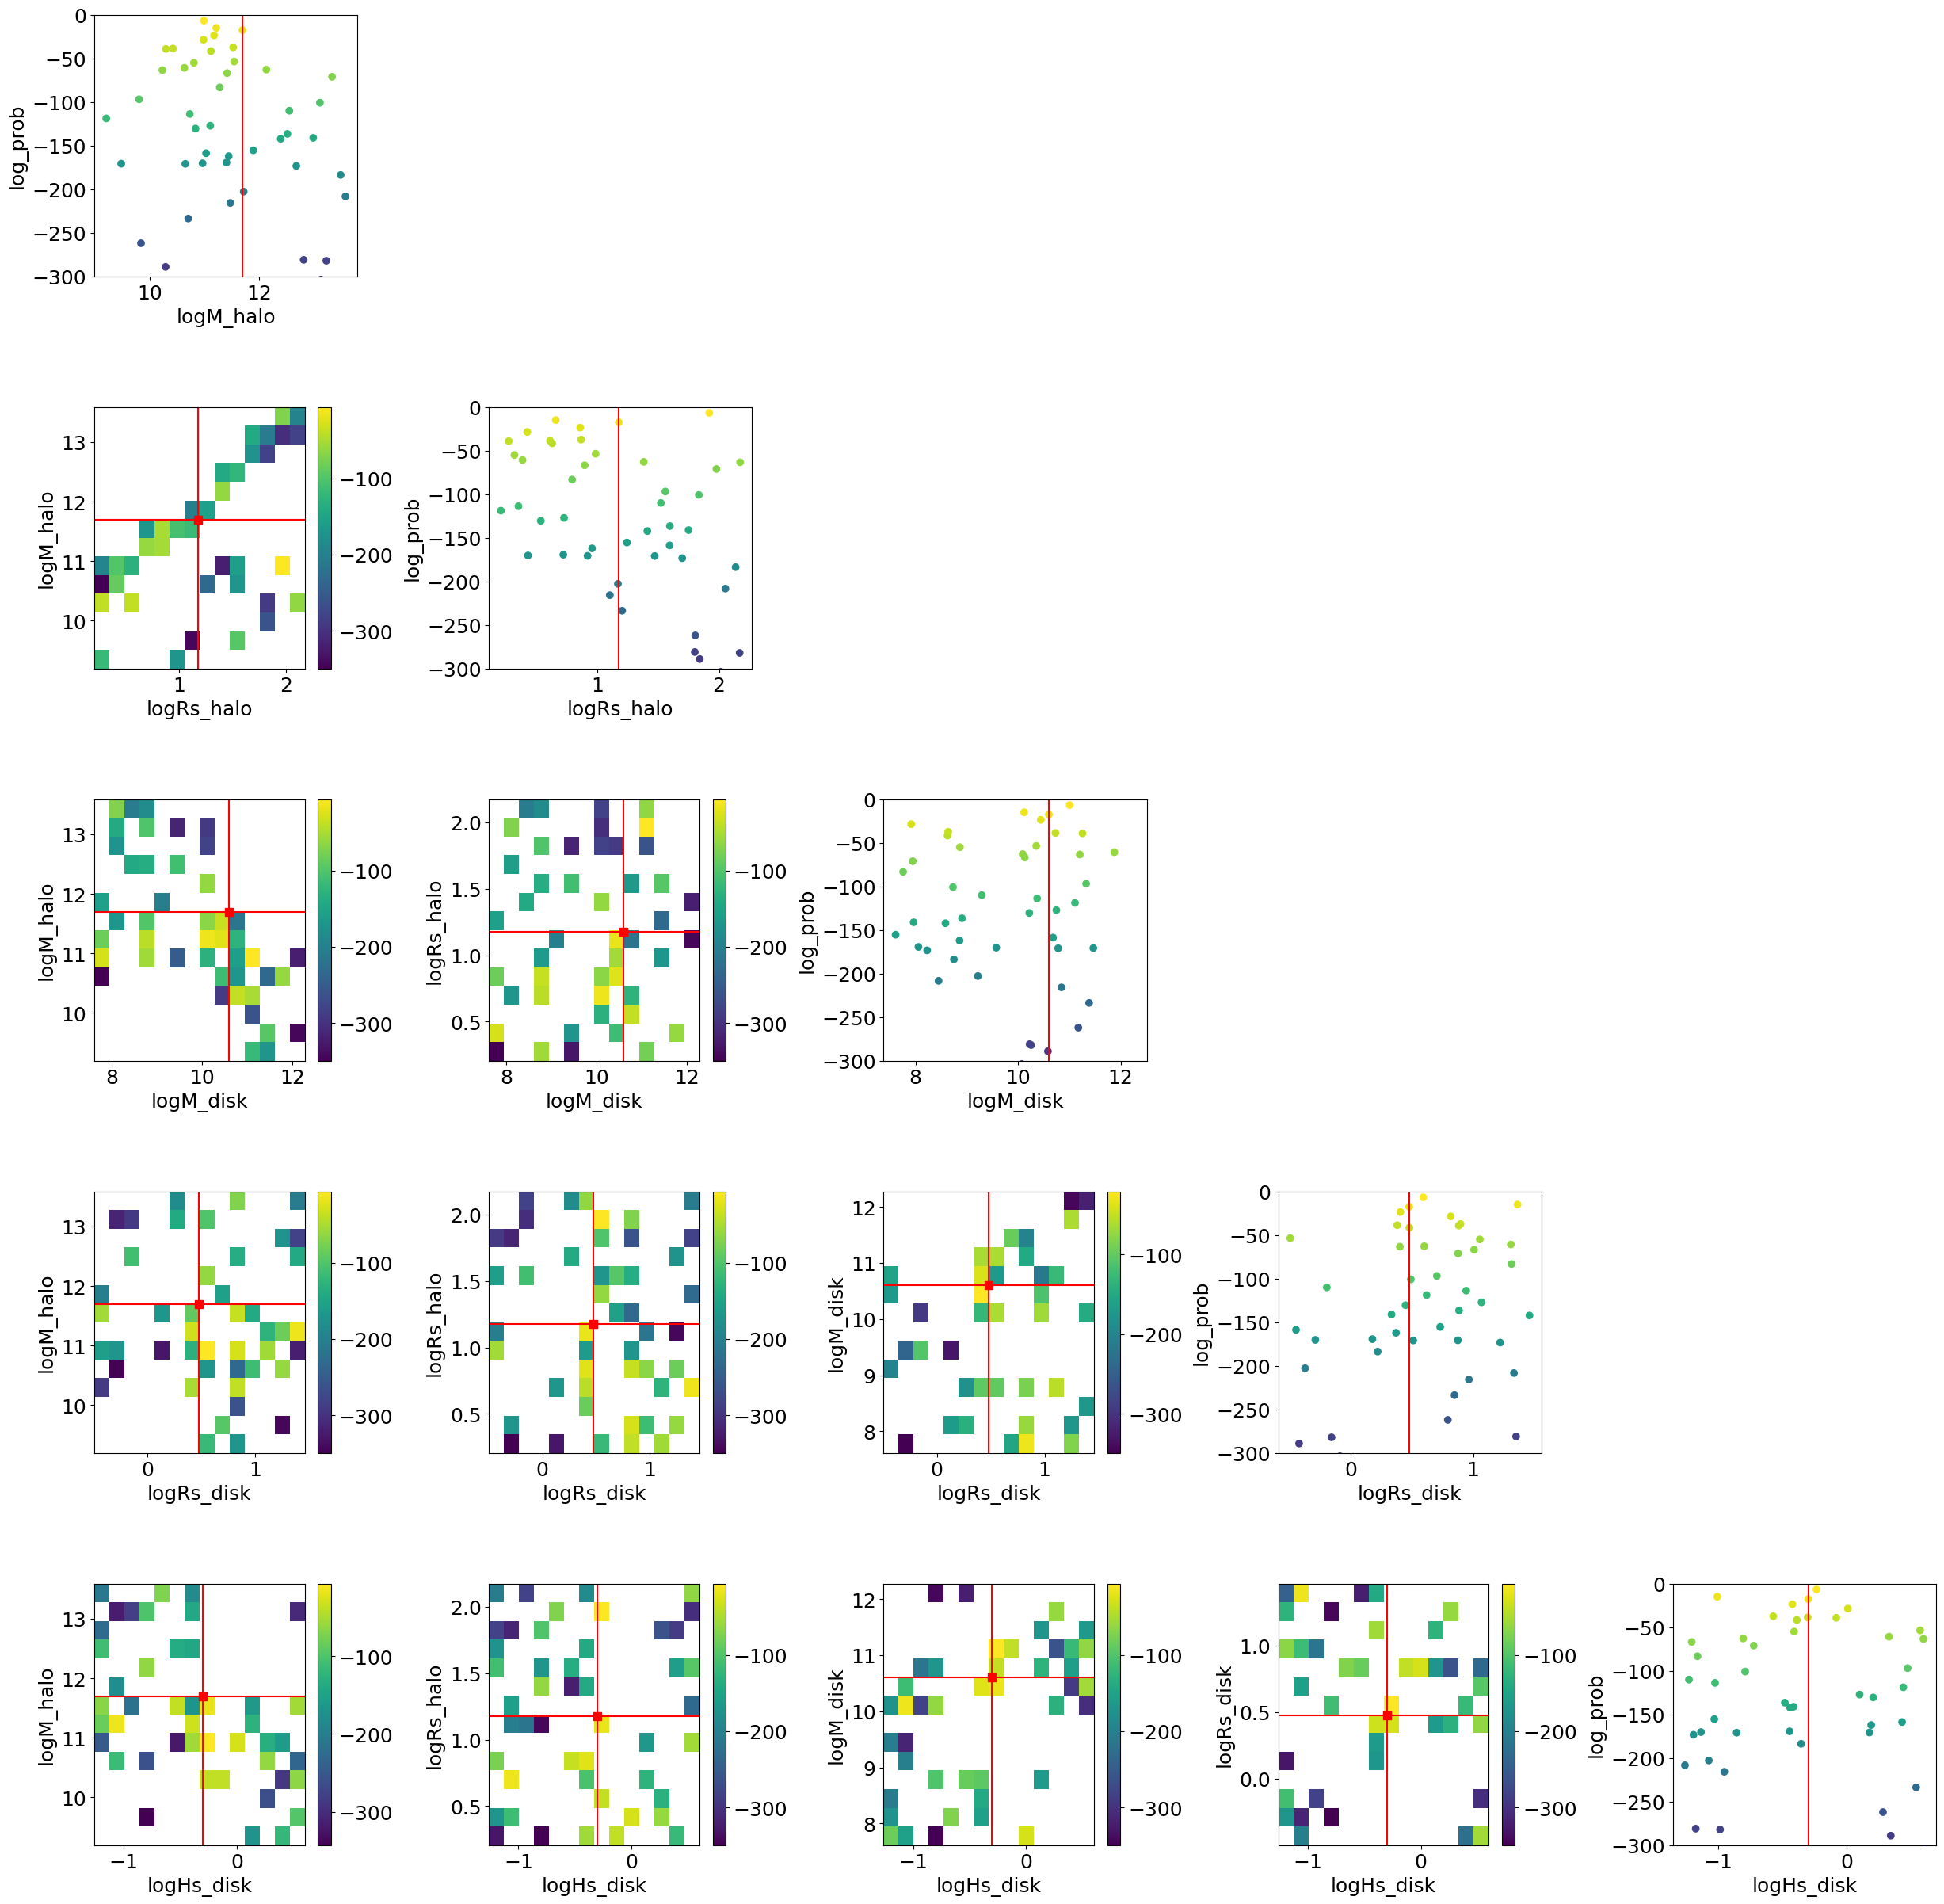

In [20]:
param_names = ['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

PATH_DATA = f'/home/hz420/python_script/SchwarMAX'
with open(PATH_DATA + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item(),
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
}

df_param = pd.read_csv('/data/hz420-2/SchwarMAX/grid_search_result_0203.csv')
df_param = df_param[df_param['log_prob'] > np.percentile(df_param['log_prob'], 95)]

fig, ax = plt.subplots(len(param_names), len(param_names), figsize = (6* len(param_names), 6* len(param_names)),
                       gridspec_kw={'hspace': 0.5, 'wspace': 0.5})

for i in range (len(param_names)):
  for j in range (len(param_names)):

    if i>j:
      xedge = np.linspace(np.amin(df_param[param_names[i]]), np.amax(df_param[param_names[i]]), 15)
      yedge = np.linspace(np.amin(df_param[param_names[j]]), np.amax(df_param[param_names[j]]), 15)
      xmid, ymid = (xedge[1:]+xedge[:-1])/2, (yedge[1:]+yedge[:-1])/2
      H, xedge, yedge = np.histogram2d(df_param[param_names[i]], df_param[param_names[j]], bins = [xedge, yedge])
      H_val = np.histogram2d(df_param[param_names[i]], df_param[param_names[j]], bins = [xedge, yedge], weights = df_param['log_prob'])[0] / (H)
      # cb = ax[i,j].scatter(df_param[param_names[i]], df_param[param_names[j]], c=df_param['log_prob'], cmap='viridis',vmin=-3e3)
      cb = ax[i,j].pcolormesh(xedge, yedge, H_val.T, cmap='viridis', )
      # ax[i,j].contour(xmid, ymid, H_val.T, levels = [-3000,-2000,-1000,-500])
      ax[i,j].set_xlabel(param_names[i])
      ax[i,j].set_ylabel(param_names[j])
      ax[i,j].axvline(x=ground_truth[param_names[i]], color='red')
      ax[i,j].axhline(y=ground_truth[param_names[j]], color='red')
      ax[i,j].scatter(ground_truth[param_names[i]], ground_truth[param_names[j]], color='red', marker='s', s=50)
      fig.colorbar(cb, ax = ax[i,j])

    elif i<j:
      ax[i,j].set_axis_off()

    else:
      ax[i,j].scatter(df_param[param_names[i]], df_param['log_prob'], c=df_param['log_prob'], cmap='viridis')
      ax[i,j].set_xlabel(param_names[i])
      ax[i,j].set_ylabel('log_prob')
      ax[i,j].axvline(x=ground_truth[param_names[i]], color='red')
      ax[i,j].set(ylim=[-3e2, 0])

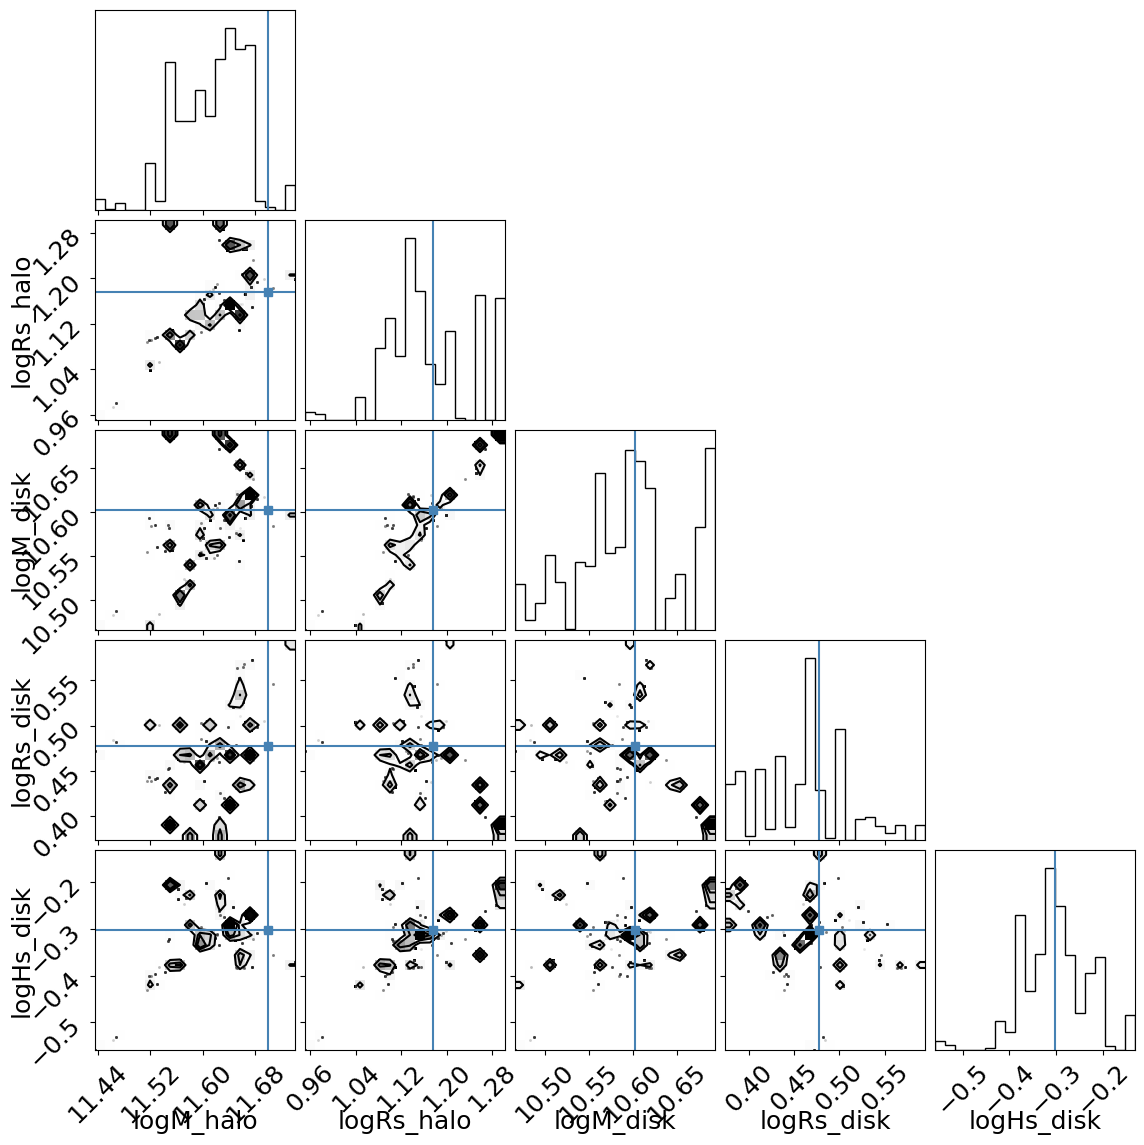

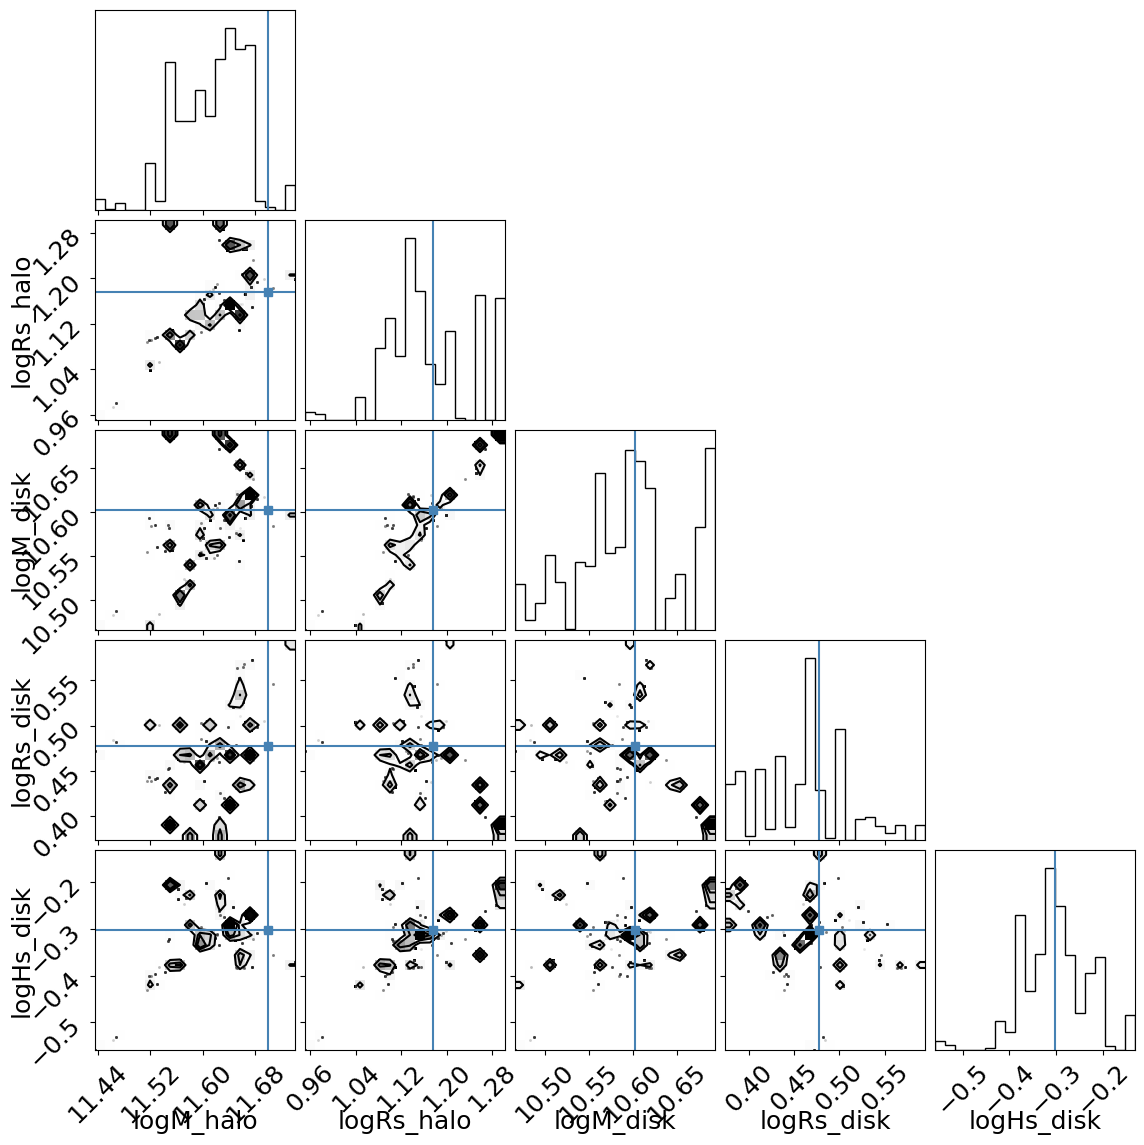

In [15]:
import pandas as pd


param_names = ['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

PATH_DATA = f'/home/hz420/python_script/SchwarMAX'
with open(PATH_DATA + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item(),
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
}


# samples_plot = samples
samples_plot = pd.read_csv('/data/hz420-2/SchwarMAX/test_posterior_0201.csv').to_numpy()
ground_truth_plot = [ground_truth[k] for k in param_names]
corner.corner(samples_plot, labels=param_names, truths=ground_truth_plot)

In [80]:
help(PowerBin), pow.bin_num, pow.xybin

Help on class PowerBin in module powerbin.powerbin:

class PowerBin(builtins.object)
 |  PowerBin(xy: Union[collections.abc.Buffer, numpy._typing._array_like._SupportsArray[numpy.dtype[Any]], numpy._typing._nested_sequence._NestedSequence[numpy._typing._array_like._SupportsArray[numpy.dtype[Any]]], bool, int, float, complex, str, bytes, numpy._typing._nested_sequence._NestedSequence[Union[bool, int, float, complex, str, bytes]]], capacity_spec: Union[Callable, collections.abc.Buffer, numpy._typing._array_like._SupportsArray[numpy.dtype[Any]], numpy._typing._nested_sequence._NestedSequence[numpy._typing._array_like._SupportsArray[numpy.dtype[Any]]], bool, int, float, complex, str, bytes, numpy._typing._nested_sequence._NestedSequence[Union[bool, int, float, complex, str, bytes]]], target_capacity: float, pixelsize: float | None = None, verbose: int = 1, regul: bool = True, args: tuple = (), maxiter: int = 50) -> None
 |
 |  PowerBin Class
 |  ==============
 |
 |  PowerBin Purpose
 |  -

(None,
 array([319, 319, 319, ..., 318, 318, 318]),
 array([[ 1.99999571e-01,  1.99999809e-02],
        [ 1.99999571e-01, -1.99999958e-02],
        [-2.00000286e-01, -1.99999958e-02],
        [-2.00000286e-01,  1.99999809e-02],
        [-2.00000286e-01, -6.00000173e-02],
        [-6.00000203e-01, -1.99999958e-02],
        [-2.00000286e-01,  5.99999428e-02],
        [ 1.99999571e-01,  5.99999428e-02],
        [ 1.99999571e-01, -6.00000173e-02],
        [ 5.99999428e-01, -1.99999958e-02],
        [ 5.99999428e-01, -6.00000173e-02],
        [-6.00000203e-01,  1.99999809e-02],
        [ 5.99999428e-01,  1.99999809e-02],
        [ 1.99999571e-01, -1.00000024e-01],
        [-6.00000203e-01, -6.00000173e-02],
        [-2.00000286e-01,  9.99999642e-02],
        [-2.00000286e-01, -1.00000024e-01],
        [ 1.99999571e-01,  9.99999642e-02],
        [-6.00000203e-01,  5.99999428e-02],
        [-1.00000036e+00,  1.99999809e-02],
        [ 9.99999344e-01,  1.99999809e-02],
        [ 5.99999428e-01

<class 'numpy.ndarray'> [5.33 5.31 5.47 ... 4.6  5.56 5.63]
Bin-accretion Delaunay...
405  initial bins.
376  good bins.
Regularization...
Bins: 376; Single Pixels: 105/3107
Capacity Fractional RMS Scatter (%): 12.86
Time Accretion: 0.15 s
Time Regularization (it=18): 0.09 s


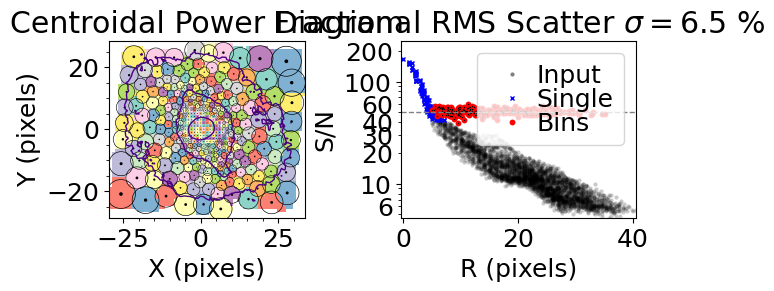

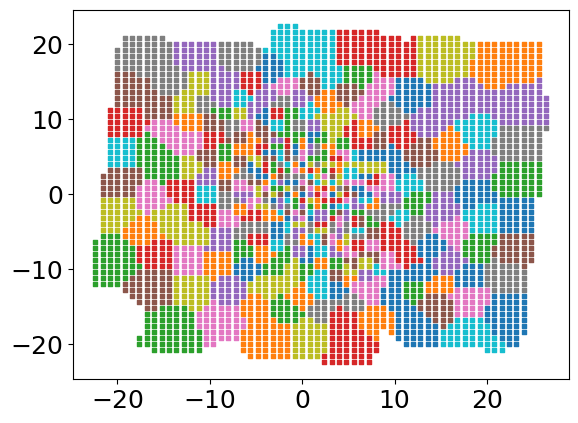

In [90]:
from importlib import resources
import numpy as np
import matplotlib.pyplot as plt
from powerbin import PowerBin

# Load example data: x, y, signal, noise
data_path = resources.files('powerbin') / 'examples/sample_data_ngc2273.txt'
x, y, signal, noise = np.loadtxt(data_path).T
xy = np.column_stack([x, y])

print(type(signal), noise)
target_sn = 50

# --- Define Capacity Specification ---
# Toggle this flag to switch between the two methods.
additive = False

if additive:
    # 1. Additive case: Provide a pre-calculated array of pixel capacities.
    # This is efficient for capacities like (S/N)^2 with Poissonian noise.
    capacity_spec = (signal / noise)**2

else:
    # 2. Non-additive case: Provide a function for custom capacity logic.
    def capacity_spec(index):
        """Calculates (S/N)^2 for a bin from its pixel indices."""
        # Standard S/N formula for uncorrelated noise
        sn = np.sum(signal[index]) / np.sqrt(np.sum(noise[index]**2))
        # Example for correlated noise (see full example file for details):
        # sn /= 1 + 1.07 * np.log10(len(index))
        return sn**2

# Perform the binning. The target is target_sn**2 to match the capacity definition.
pow = PowerBin(xy, capacity_spec, target_capacity=target_sn**2)

# Plot the results. We use capacity_scale='sqrt' to display S/N instead of (S/N)^2.
pow.plot(capacity_scale='sqrt', ylabel='S/N')

bin_index_remap = pow.bin_num
plt.figure()
for i in range (np.amax(bin_index_remap)):
    bin_coords = xy[bin_index_remap == i]

    plt.scatter(bin_coords[:, 0], bin_coords[:, 1], s = 10,  marker = 's')
    



# Renormalise the density contribution to the logL when calculating the orbital weights!!! Rescale it to unity

# h_i = \Sum_j^{N_orb} h_i,j x N_j x w_j / (N_j x w_j) --> S_i for linear 

# Grid search first before MCMC

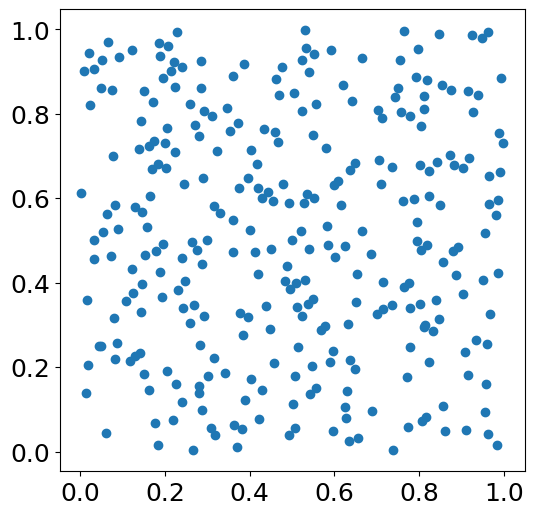

In [106]:
from scipy.stats import qmc
sampler = qmc.Sobol(d=5, scramble=False)
sample = sampler.random_base2(m=10)

# sample2 = np.random.uniform(0,1,size=(1024,5))
random_index = np.random.choice(len(sample), size=300, replace=False)
sample = sample[random_index]

plt.figure(figsize=(6,6))
plt.scatter(sample[:,0], sample[:,2])
# plt.scatter(sample2[:,0], sample2[:,2], alpha=0.7, color='orange')

# cb = plt.hist2d(sample[:,0], sample[:,1], bins=30, cmap='viridis')
# plt.colorbar(cb[3], label='Counts')

# pd.DataFrame(sample, 
# columns=['col0', 'col1', 'col2', 'col3', 'col4']
# ).to_csv(path + 'quasi_random_samples_5D_unity.csv', index=False)

# debuging

In [52]:

@jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val

@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).
    
    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)
    
    # --- Step 1: Compute Sigma_z (Vertical Integration) ---
    
    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)
    
    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
    
    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0
    
    sigma_z2 = (1.0 / nu_val) * integral_val
    
    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)
    
    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)
    
    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR
    
    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)
        
        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)
    
    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)
    
    v_phi_total_sq = term1 + term2 + term3
    
    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R
    
    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))
    
    return output


# @jax.jit
def _nll_z(z, 
            A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4, 
            y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
            sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2):

    x = jnn.softplus(z)  # strictly positive
    # jax.debug.print("A_Rzphi's shape: {x_norm}", x_norm=A_Rzphi.shape)
    # jax.debug.print("x's shape: {x_norm}", x_norm=x.shape)
    r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi

    density_2DXY = A_xy @ x
    r_2dXY = (density_2DXY - y_xy) / sig_xy

    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    r_h1 = ( (A_h1 @ x) / y_xy - y_h1 ) / sig_A1
    r_h2 = ( (A_h2 @ x) / y_xy - y_h2 ) / sig_A2
    r_h3 = ( (A_h3 @ x) / y_xy - y_h3 ) / sig_A3
    r_h4 = ( (A_h4 @ x) / y_xy - y_h4 ) / sig_A4

    val1 = 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi)
    val2 = 0.5 * jnp.dot(r_2dXY, r_2dXY)
    val3 = 0.5 * jnp.dot(r_h1, r_h1)
    val4 = 0.5 * jnp.dot(r_h2, r_h2)
    val5 = 0.5 * jnp.dot(r_h3, r_h3)
    val6 = 0.5 * jnp.dot(r_h4, r_h4)

    return val1 + val2 + val3 + val4 + val5 + val6 + 0.5 * l2 * jnp.dot(x, x)#
_nll_z = jax.value_and_grad(_nll_z)

# @jax.jit
def solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                        y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                        sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                        l2=1e-3, maxiter=1000, tol=1e-6):
    z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0, 
                    A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat


# @jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 2500
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        jnp.array([[0,10.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-8.,8.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
                        v0, s)

    jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    print("h1 shape: {x_norm}",h1.shape)
    print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    print("h1 non zero: {x_norm}",(h1!=0).sum())
    print("h2 shape: {x_norm}",h2.shape)
    print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    print("h2 non zero: {x_norm}",(h2!=0).sum())
    print("h3 shape: {x_norm}",h3.shape)
    print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    print("h3 non zero: {x_norm}",(h3!=0).sum())
    print("h4 shape: {x_norm}",h4.shape)
    print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    print("h4 non zero: {x_norm}",(h4!=0).sum())
    print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = Nxy.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    A_h1 = jnp.where(jnp.fabs(A_h1)>2, 0.0, A_h1)
    A_h2 = jnp.where(jnp.fabs(A_h2)>2, -1/np.sqrt(2), A_h2)
    A_h3 = jnp.where(jnp.fabs(A_h3)>2, 0.0, A_h3)
    A_h4 = jnp.where(jnp.fabs(A_h4)>2, 3/np.sqrt(24), A_h4)

    y_Rzphi = dict_data['Rzphi_density_data'].astype(jnp.float32)
    y_xy = dict_data['XY_density_data'].astype(jnp.float32)
    y_h1 = dict_data['h1_data'].astype(jnp.float32)
    y_h2 = dict_data['h2_data'].astype(jnp.float32)
    y_h3 = dict_data['h3_data'].astype(jnp.float32)
    y_h4 = dict_data['h4_data'].astype(jnp.float32)

    sig_Rzphi = 0.02 * y_Rzphi + 1.0
    sig_xy = 0.01 * y_xy + 1.0
    frac_err_min = 0.1
    sig_A1 = jnp.where(frac_err_min * y_h1 > dict_data['h1_data_err'], frac_err_min * y_h1, dict_data['h1_data_err']) + EPSILON
    sig_A2 = jnp.where(frac_err_min * y_h2 > dict_data['h2_data_err'], frac_err_min * y_h2, dict_data['h2_data_err']) + EPSILON
    sig_A3 = jnp.where(frac_err_min * y_h3 > dict_data['h3_data_err'], frac_err_min * y_h3, dict_data['h3_data_err']) + EPSILON
    sig_A4 = jnp.where(frac_err_min * y_h4 > dict_data['h4_data_err'], frac_err_min * y_h4, dict_data['h4_data_err']) + EPSILON

    renormalise_Rzphi = jnp.amax(y_Rzphi)
    renormalise_xy = jnp.amax(y_xy)
    renormalise_h1 = jnp.amax(jnp.fabs(y_h1))
    renormalise_h2 = jnp.amax(jnp.fabs(y_h2))
    renormalise_h3 = jnp.amax(jnp.fabs(y_h3))
    renormalise_h4 = jnp.amax(jnp.fabs(y_h4))

    y_xy = y_xy / renormalise_xy
    A_xy = A_xy / renormalise_xy
    sig_xy = sig_xy / renormalise_xy
    y_Rzphi = y_Rzphi / renormalise_Rzphi
    A_Rzphi = A_Rzphi / renormalise_Rzphi
    sig_Rzphi = sig_Rzphi / renormalise_Rzphi
    y_h1 = y_h1 / renormalise_h1
    A_h1 = A_h1 / renormalise_h1
    sig_A1 = sig_A1 / renormalise_h1
    y_h2 = y_h2 / renormalise_h2
    A_h2 = A_h2 / renormalise_h2
    sig_A2 = sig_A2 / renormalise_h2
    y_h3 = y_h3 / renormalise_h3
    A_h3 = A_h3 / renormalise_h3
    sig_A3 = sig_A3 / renormalise_h3
    y_h4 = y_h4 / renormalise_h4
    A_h4 = A_h4 / renormalise_h4
    sig_A4 = sig_A4 / renormalise_h4

    non_empty_index = dict_data['non_empty_index']
    y_xy = y_xy[non_empty_index]
    A_xy = A_xy[non_empty_index,:]
    sig_xy = sig_xy[non_empty_index]
    y_h1 = y_h1[non_empty_index]
    A_h1 = A_h1[non_empty_index,:]
    sig_A1 = sig_A1[non_empty_index]
    y_h2 = y_h2[non_empty_index]
    A_h2 = A_h2[non_empty_index,:]
    sig_A2 = sig_A2[non_empty_index]
    y_h3 = y_h3[non_empty_index]
    A_h3 = A_h3[non_empty_index,:]
    sig_A3 = sig_A3[non_empty_index]
    y_h4 = y_h4[non_empty_index]
    A_h4 = A_h4[non_empty_index,:]
    sig_A4 = sig_A4[non_empty_index]

    v0 = v0[non_empty_index]
    s = s[non_empty_index]

    print("N_xy data nan:",jnp.isnan(y_xy).sum())
    print("N_xy data non zero:",(y_xy!=0).sum())
    print('sigma_xy nan:',jnp.isnan(sig_xy).sum())
    print('sigma_xy non zero:',(sig_xy!=0).sum())
    print("h1 data nan:",jnp.isnan(y_h1).sum())
    print("h1 data non zero:",(y_h1!=0).sum())
    print("sigma_h1 nan:",jnp.isnan(sig_A1).sum())
    print("sigma_h1 non zero:",(sig_A1!=0).sum())
    print("h2 data nan:",jnp.isnan(y_h2).sum())
    print("h2 data non zero:",(y_h2!=0).sum())
    print("sigma_h2 nan:",jnp.isnan(sig_A2).sum())
    print("sigma_h2 non zero:",(sig_A2!=0).sum())
    print("h3 data nan:",jnp.isnan(y_h3).sum())
    print("h3 data non zero:",(y_h3!=0).sum())
    print("sigma_h3 nan:",jnp.isnan(sig_A3).sum())
    print("sigma_h3 non zero:",(sig_A3!=0).sum())
    print("h4 data nan:",jnp.isnan(y_h4).sum())
    print("h4 data non zero:",(y_h4!=0).sum())
    print("sigma_h4 nan:",jnp.isnan(sig_A4).sum())
    print("sigma_h4 non zero:",(sig_A4!=0).sum())
    
    weights = solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, 
                                    l2=1e-3, maxiter=500)

    weights = jnn.softplus(weights)

    #===================================== Calculate the net kinematics of the model =========================================


    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    density_2DXY = A_xy @ weights
    h1_model = (A_h1 @ weights) / density_2DXY
    h2_model = (A_h2 @ weights) / density_2DXY
    h3_model = (A_h3 @ weights) / density_2DXY
    h4_model = (A_h4 @ weights) / density_2DXY

    V_model, sigma_model = h_to_V_sigma(h1_model, h2_model, v0, s)
    

    return V_model, sigma_model, h3_model, h4_model, weights


# @jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    V_model, sigma_model, h3_model, h4_model, weights = model(params_halo_pot, params_disk_rho, dict_data)

    jax.debug.print("`V_model` shape: {x_norm}", x_norm=V_model.shape)
    jax.debug.print("V_model with nan: {x_norm}", x_norm=jnp.isnan(V_model).sum())
    jax.debug.print("`V_model`: {x_norm}", x_norm=V_model)
    jax.debug.print("`sigma_model`: {x_norm}", x_norm=sigma_model)
    jax.debug.print("`weights`: {x_norm}", x_norm=weights)
    jax.debug.print("`weights 16th`: {x_norm}", x_norm=jnp.percentile(weights, 16))
    jax.debug.print("`weights 84th`: {x_norm}", x_norm=jnp.percentile(weights, 84))
    jax.debug.print("weights with nan: {x_norm}", x_norm=jnp.isnan(weights).sum())

    V_model = jnp.where(jnp.isnan(V_model), 0.0, V_model)
    sigma_model = jnp.where(jnp.isnan(sigma_model), 0.0, sigma_model)
    h3_model = jnp.where(jnp.isnan(h3_model), 0.0, h3_model)
    h4_model = jnp.where(jnp.isnan(h4_model), 0.0, h4_model)

    V_data, V_data_err = dict_data['V_data'], dict_data['V_data_err']
    sigma_data, sigma_data_err = dict_data['sigma_data'], dict_data['sigma_data_err']
    h3_data, h3_data_err = dict_data['h3_data'], dict_data['h3_data_err']
    h4_data, h4_data_err = dict_data['h4_data'], dict_data['h4_data_err']

    non_empty_index = dict_data['non_empty_index']
    V_data = V_data[non_empty_index]
    V_data_err = V_data_err[non_empty_index]
    sigma_data = sigma_data[non_empty_index]
    sigma_data_err = sigma_data_err[non_empty_index]
    h3_data = h3_data[non_empty_index]
    h3_data_err = h3_data_err[non_empty_index]
    h4_data = h4_data[non_empty_index]
    h4_data_err = h4_data_err[non_empty_index]

    jax.debug.print("V diff mean sigma_model: {x_norm}, {sigma}", 
                    x_norm=jnp.nanmean(jnp.fabs(V_model - V_data)), sigma=jnp.nanstd(jnp.fabs(V_model - V_data)))
    
    jax.debug.print("sigma diff mean sigma_model: {x_norm}, {sigma}", 
                    x_norm=jnp.nanmean(jnp.fabs(sigma_model - sigma_data)), sigma=jnp.nanstd(jnp.fabs(sigma_model - sigma_data)))
    
    jax.debug.print("h3 diff mean sigma_model: {x_norm}, {sigma}", 
                    x_norm=jnp.nanmean(jnp.fabs(h3_model - h3_data)), sigma=jnp.nanstd(jnp.fabs(h3_model - h3_data)))
    
    jax.debug.print("h4 diff mean sigma_model: {x_norm}, {sigma}", 
                    x_norm=jnp.nanmean(jnp.fabs(h4_model - h4_data)), sigma=jnp.nanstd(jnp.fabs(h4_model - h4_data)))


    frac_err_min = 0.1
    V_data_err = jnp.where(frac_err_min * V_data > V_data_err, frac_err_min * V_data, V_data)
    sigma_data_err = jnp.where(frac_err_min * sigma_data > sigma_data_err, frac_err_min * sigma_data, sigma_data)
    h3_data_err = jnp.where(frac_err_min * h3_data > h3_data_err, frac_err_min * h3_data, h3_data)
    h4_data_err = jnp.where(frac_err_min * h4_data > h4_data_err, frac_err_min * h4_data, h4_data)

    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((V_model - V_data)**2) / (V_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((sigma_model - sigma_data)**2) / (sigma_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((h3_model - h3_data)**2) / (h3_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((h4_model - h4_data)**2) / (h4_data_err + 1e-3)**2 )

    return log_likelihood

In [60]:
with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(ic['x']), size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)

non_empty_index = jnp.where(df_XY_data['nonempty'].to_numpy())[0]



dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'non_empty_index': non_empty_index
}

i = 16
ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}


logL, V_model, sigma_model, h3_model, h4_model = logl(ground_truth, dict_data)
print(logL)

10000
h1 shape: (Array(10000, dtype=int32, weak_type=True), Array(1200, dtype=int32, weak_type=True))
h1 nan: 0
h1 shape: {x_norm} (10000, 1200)
h1 nan: {x_norm} 0
h1 non zero: {x_norm} 4637854
h2 shape: {x_norm} (10000, 1200)
h2 nan: {x_norm} 0
h2 non zero: {x_norm} 12000000
h3 shape: {x_norm} (10000, 1200)
h3 nan: {x_norm} 0
h3 non zero: {x_norm} 4637854
h4 shape: {x_norm} (10000, 1200)
h4 nan: {x_norm} 0
h4 non zero: {x_norm} 12000000
Nxy nan: {x_norm} 0
Nxy non zero: {x_norm} 4637854
N_xy data nan: 0
N_xy data non zero: 1120
sigma_xy nan: 0
sigma_xy non zero: 1120
h1 data nan: 0
h1 data non zero: 1120
sigma_h1 nan: 0
sigma_h1 non zero: 1120
h2 data nan: 0
h2 data non zero: 1120
sigma_h2 nan: 0
sigma_h2 non zero: 1120
h3 data nan: 0
h3 data non zero: 1120
sigma_h3 nan: 0
sigma_h3 non zero: 1120
h4 data nan: 0
h4 data non zero: 1120
sigma_h4 nan: 0
sigma_h4 non zero: 1120
`V_model` shape: (Array(1120, dtype=int32, weak_type=True),)
V_model with nan: 0
`V_model`: [ 138.74477  143.4661

In [51]:
df_XY_data['X_grid'][non_empty_index].shape, V_model.shape

AttributeError: 'int' object has no attribute 'shape'

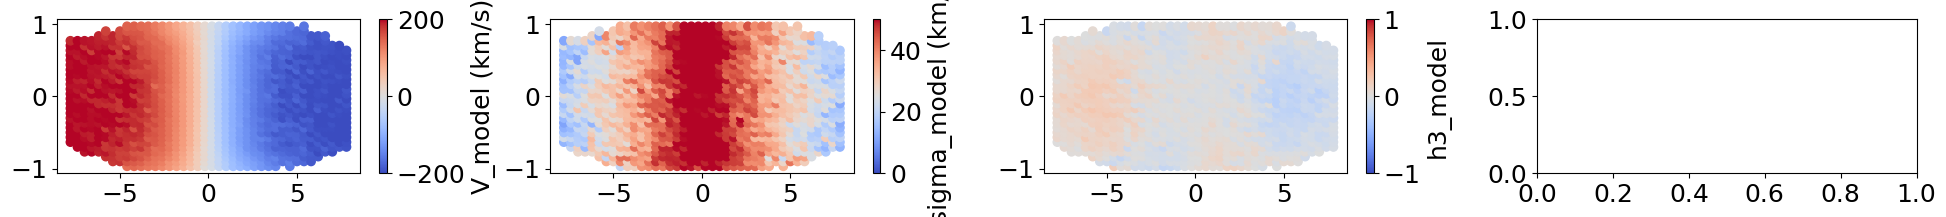

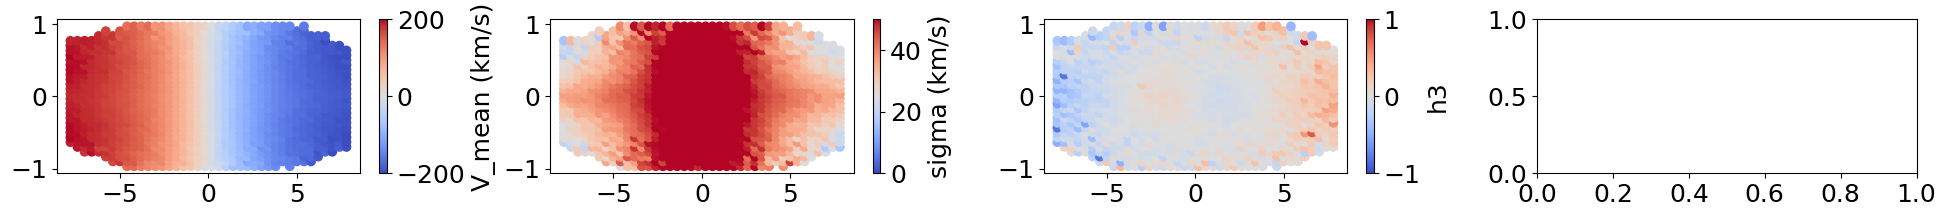

In [61]:
fig0, ax0 = plt.subplots(1,4, figsize=(24,2), gridspec_kw={'wspace': 0.3})
fig1, ax1 = plt.subplots(1,4, figsize=(24,2), gridspec_kw={'wspace': 0.3})

cb = ax0[0].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=V_model, vmin=-200, vmax=200, cmap='coolwarm')
fig0.colorbar(cb, ax=ax0[0], label='V_model (km/s)')

cb = ax1[0].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=df_XY_data['V_mean'][non_empty_index], vmin=-200, vmax=200, cmap='coolwarm')
fig1.colorbar(cb, ax=ax1[0], label='V_mean (km/s)')

cb = ax0[1].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=sigma_model, vmin=0, vmax=50, cmap='coolwarm')
fig0.colorbar(cb, ax=ax0[1], label='sigma_model (km/s)')

cb = ax1[1].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=df_XY_data['V_sigma'][non_empty_index], vmin=0, vmax=50, cmap='coolwarm')
fig1.colorbar(cb, ax=ax1[1], label='sigma (km/s)')

cb = ax0[2].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=h3_model, vmin=-1, vmax=1, cmap='coolwarm')
fig0.colorbar(cb, ax=ax0[2], label='h3_model')

cb = ax1[2].scatter(df_XY_data['X_grid'][non_empty_index], df_XY_data['Y_grid'][non_empty_index], c=df_XY_data['h3'][non_empty_index], vmin=-1, vmax=1, cmap='coolwarm')
fig1.colorbar(cb, ax=ax1[2], label='h3')